# Оценка качества извлечения по метрикам refactored-результатов

Ноутбук считает метрики качества извлечения (`char_f1`, `token_f1`, `rouge_l_f1`, опционально BERTScore)
для JSON-результатов refactored-пайплайна и сравнивает комбинации стратегий.

**Источники данных:**
- `artifacts/results_keys_refactored.json` (EN / SciREx)
- `artifacts/results_keys_rus_refactored.json` (RU / RuSERRC)

**Эталон:** `tasks_cleaned`, **предсказание:** `final_answer`.

Артефакты сохраняются в `experiments/analysis_results/extraction_metrics/`.


In [1]:
from __future__ import annotations

from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


def find_project_root(start: Path | None = None) -> Path:
    start = start or Path.cwd()
    for candidate in (start, *start.parents):
        if (candidate / "untie" / "extraction_metrics.py").is_file() and (candidate / "pyproject.toml").is_file():
            return candidate
    raise RuntimeError(
        "Не найден корень UnTIE. Откройте ноутбук из POLINA/UnTIE_project и перезапустите kernel."
    )


PROJECT_ROOT = find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from untie.extraction_metrics import METRIC_COLUMNS, compute_metrics_rowwise
from untie.results_analysis import (
    STRATEGY_COLUMNS,
    filter_valid_rows,
    load_results,
    project_root,
    split_evaluable_rows,
    strategy_applicability_summary,
)

try:
    import seaborn as sns
    HAS_SEABORN = True
except ImportError:
    HAS_SEABORN = False

ARTIFACTS_DIR = project_root() / "artifacts"
OUTPUT_DIR = project_root() / "experiments" / "analysis_results" / "extraction_metrics"
FIGURES_DIR = OUTPUT_DIR / "figures"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

DATASETS = {
    "en": {
        "path": ARTIFACTS_DIR / "results_keys_refactored.json",
        "lang": "en",
        "label": "EN / SciREx",
    },
    "ru": {
        "path": ARTIFACTS_DIR / "results_keys_rus_refactored.json",
        "lang": "ru",
        "label": "RU / RuSERRC",
    },
}

# Настройки подсчёта
INCLUDE_BERTSCORE = True  # True — очень медленно, нужны torch + bert-score
SHOW_PROGRESS = True
USE_CACHE = True  # повторный запуск читает CSV вместо пересчёта
RECOMPUTE = False  # True — принудительный пересчёт метрик

BASE_PLOT_METRICS = ["char_f1", "token_f1_norm", "rouge_l_f1"]
BERTSCORE_PLOT_METRICS = ["bertscore_p", "bertscore_r", "bertscore_f1"]
PLOT_METRICS = BASE_PLOT_METRICS.copy()
METRIC_LABELS = {
    "char_f1": "Char F1",
    "token_f1_norm": "Token F1",
    "rouge_l_f1": "ROUGE-L F1",
    "bertscore_f1": "BERTScore F1",
    "bertscore_p": "BERTScore P",
    "bertscore_r": "BERTScore R",
}

COLORS = {
    "char_f1": "#2ecc71",
    "token_f1_norm": "#3498db",
    "rouge_l_f1": "#9b59b6",
    "bertscore_f1": "#e67e22",
    "bertscore_p": "#f39c12",
    "bertscore_r": "#d35400",
}


def _has_bertscore_columns(df: pd.DataFrame) -> bool:
    return any(
        column in df.columns and df[column].notna().any()
        for column in BERTSCORE_PLOT_METRICS
    )


def resolve_plot_metrics(df: pd.DataFrame | None = None) -> list[str]:
    """Возвращает метрики для графиков с учётом фактически посчитанных колонок."""
    metrics = BASE_PLOT_METRICS.copy()
    if (df is not None and _has_bertscore_columns(df)) or INCLUDE_BERTSCORE:
        metrics.extend(m for m in BERTSCORE_PLOT_METRICS if m not in metrics)
    return metrics


def resolve_display_cols(summary: pd.DataFrame) -> list[str]:
    """Колонки таблиц summary с BERTScore, если они есть."""
    cols = ["char_f1_mean", "token_f1_norm_mean", "rouge_l_f1_mean"]
    for name in ("bertscore_p_mean", "bertscore_r_mean", "bertscore_f1_mean"):
        if name in summary.columns:
            cols.append(name)
    cols.extend(["composite_extraction", "count"])
    return cols



In [2]:
def gold_key(value) -> tuple[str, ...]:
    if isinstance(value, list):
        return tuple(str(item).strip() for item in value if str(item).strip())
    if value is None or (isinstance(value, float) and np.isnan(value)):
        return tuple()
    text = str(value).strip()
    return (text,) if text else tuple()


def active_metric_columns(include_bertscore: bool = INCLUDE_BERTSCORE) -> list[str]:
    cols = ["char_f1", "token_f1", "rouge_l_f1"]
    if include_bertscore:
        cols.extend(["bertscore_p", "bertscore_r", "bertscore_f1"])
    return cols


def attach_extraction_metrics(
    df: pd.DataFrame,
    *,
    pred_col: str = "final_answer",
    gold_col: str = "tasks_cleaned",
    lang: str = "en",
    include_bertscore: bool = INCLUDE_BERTSCORE,
    show_progress: bool = SHOW_PROGRESS,
) -> pd.DataFrame:
    """Считает метрики один раз на уникальную пару (pred, gold) и мёрджит обратно."""
    work = df.copy()
    work["_gold_key"] = work[gold_col].apply(gold_key)

    unique_pairs = (
        work.drop_duplicates(subset=[pred_col, "_gold_key"])
        .loc[:, [pred_col, gold_col, "_gold_key"]]
        .reset_index(drop=True)
    )
    print(f"  уникальных пар pred/gold: {len(unique_pairs)} из {len(work)} строк")

    scored_unique = compute_metrics_rowwise(
        unique_pairs,
        pred_col=pred_col,
        gold_col=gold_col,
        lang=lang,
        include_bertscore=include_bertscore,
        show_progress=show_progress,
    )

    metric_cols = active_metric_columns(include_bertscore)
    merge_cols = [pred_col, "_gold_key", *metric_cols]
    merged = work.merge(scored_unique[merge_cols], on=[pred_col, "_gold_key"], how="left")
    merged["token_f1_norm"] = merged["token_f1"] / 100.0
    return merged.drop(columns=["_gold_key"])


def summarize_by_strategy_combo(df: pd.DataFrame) -> pd.DataFrame:
    agg_map: dict[str, tuple[str, str]] = {"count": ("doc_id", "count")}
    if "char_f1" in df.columns:
        agg_map["char_f1_mean"] = ("char_f1", "mean")
    if "rouge_l_f1" in df.columns:
        agg_map["rouge_l_f1_mean"] = ("rouge_l_f1", "mean")
    if "token_f1" in df.columns:
        agg_map["token_f1_mean"] = ("token_f1", "mean")
        agg_map["token_f1_norm_mean"] = ("token_f1_norm", "mean")
    if "bertscore_p" in df.columns:
        agg_map["bertscore_p_mean"] = ("bertscore_p", "mean")
    if "bertscore_r" in df.columns:
        agg_map["bertscore_r_mean"] = ("bertscore_r", "mean")
    if "bertscore_f1" in df.columns:
        agg_map["bertscore_f1_mean"] = ("bertscore_f1", "mean")

    summary = df.groupby(list(STRATEGY_COLUMNS), sort=True).agg(**agg_map)
    summary.index.name = "strategy_combo"

    composite_cols = [
        c
        for c in (
            "char_f1_mean",
            "token_f1_norm_mean",
            "rouge_l_f1_mean",
            "bertscore_f1_mean",
        )
        if c in summary.columns
    ]
    summary["composite_extraction"] = summary[composite_cols].mean(axis=1)
    return summary.sort_values("composite_extraction", ascending=False)


def aggregate_metric_by_strategy(df: pd.DataFrame, strategy_col: str, metric_col: str) -> pd.DataFrame:
    value_col = metric_col.replace("_norm", "") if metric_col.endswith("_norm") else metric_col
    stats = (
        df.groupby(strategy_col)
        .agg(mean=(value_col, "mean"), std=(value_col, "std"), count=("doc_id", "count"))
        .round(4)
    )
    if metric_col.endswith("_norm") and value_col in stats.columns:
        pass
    if value_col == "token_f1":
        stats["mean"] = stats["mean"] / 100.0
        stats["std"] = stats["std"] / 100.0
    stats = stats.rename(columns={"mean": f"{metric_col}_mean", "std": f"{metric_col}_std"})
    return stats


def summary_metric_column(metric: str) -> str:
    if metric == "token_f1_norm":
        return "token_f1_norm_mean"
    return f"{metric}_mean"


In [3]:
def load_or_score_dataset(lang: str, cfg: dict) -> dict:
    path = cfg["path"]
    if not path.is_file():
        raise FileNotFoundError(f"Не найден файл результатов: {path}")

    raw = load_results(path)
    valid, invalid = filter_valid_rows(raw)
    evaluable, degenerate = split_evaluable_rows(valid)
    applicability = strategy_applicability_summary(valid)

    cache_path = OUTPUT_DIR / f"scored_{lang}.csv"
    if USE_CACHE and cache_path.is_file() and not RECOMPUTE:
        print(f"[{lang.upper()}] загрузка кэша: {cache_path}")
        scored = pd.read_csv(cache_path)
        if "tasks_cleaned" in scored.columns:
            scored["tasks_cleaned"] = scored["tasks_cleaned"].apply(parse_tasks_cleaned)
    else:
        print(f"[{lang.upper()}] подсчёт метрик из {path.name}")
        scored = attach_extraction_metrics(
            valid,
            pred_col="final_answer",
            gold_col="tasks_cleaned",
            lang=cfg["lang"],
            include_bertscore=INCLUDE_BERTSCORE,
            show_progress=SHOW_PROGRESS,
        )
        scored.to_csv(cache_path, index=False, encoding="utf-8")
        print(f"  сохранено: {cache_path}")

    summary = summarize_by_strategy_combo(scored)
    summary_path = OUTPUT_DIR / f"summary_{lang}.csv"
    summary.to_csv(summary_path, encoding="utf-8")

    evaluable_scored = scored
    evaluable_summary = pd.DataFrame()
    if not evaluable.empty and "strategy_applicable" in scored.columns:
        evaluable_scored = scored[scored["strategy_applicable"].fillna(False).astype(bool)].copy()
        if not evaluable_scored.empty:
            evaluable_summary = summarize_by_strategy_combo(evaluable_scored)
            evaluable_summary.to_csv(OUTPUT_DIR / f"summary_evaluable_{lang}.csv", encoding="utf-8")

    return {
        "lang": lang,
        "label": cfg["label"],
        "raw": raw,
        "valid": valid,
        "invalid": invalid,
        "scored": scored,
        "evaluable_scored": evaluable_scored,
        "summary": summary,
        "evaluable_summary": evaluable_summary,
        "applicability": applicability,
        "summary_path": summary_path,
    }


def parse_tasks_cleaned(value):
    if isinstance(value, list):
        return value
    if value is None or (isinstance(value, float) and np.isnan(value)):
        return []
    text = str(value).strip()
    if not text:
        return []
    try:
        return json.loads(text)
    except json.JSONDecodeError:
        import ast
        return ast.literal_eval(text)


import json

results: dict[str, dict] = {}
for lang, cfg in DATASETS.items():
    if cfg["path"].is_file():
        results[lang] = load_or_score_dataset(lang, cfg)
    else:
        print(f"Пропуск {lang}: нет файла {cfg['path']}")

if results:
    PLOT_METRICS = resolve_plot_metrics(next(iter(results.values()))["scored"])
    print("Метрики для графиков:", PLOT_METRICS)

for lang, r in results.items():
    app = r["applicability"]
    print(
        f"{r['label']}: valid={len(r['valid'])}, invalid={len(r['invalid'])}, "
        f"evaluable_docs={app['evaluable_documents']}/{app['total_documents']} "
        f"({app['evaluable_documents_pct']:.1f}%)"
    )


[EN] загрузка кэша: /home/aiserver/POLINA/UnTIE_project/experiments/analysis_results/extraction_metrics/scored_en.csv
[RU] загрузка кэша: /home/aiserver/POLINA/UnTIE_project/experiments/analysis_results/extraction_metrics/scored_ru.csv
Метрики для графиков: ['char_f1', 'token_f1_norm', 'rouge_l_f1', 'bertscore_p', 'bertscore_r', 'bertscore_f1']
EN / SciREx: valid=7425, invalid=31, evaluable_docs=275/275 (100.0%)
RU / RuSERRC: valid=4212, invalid=12, evaluable_docs=128/156 (82.1%)


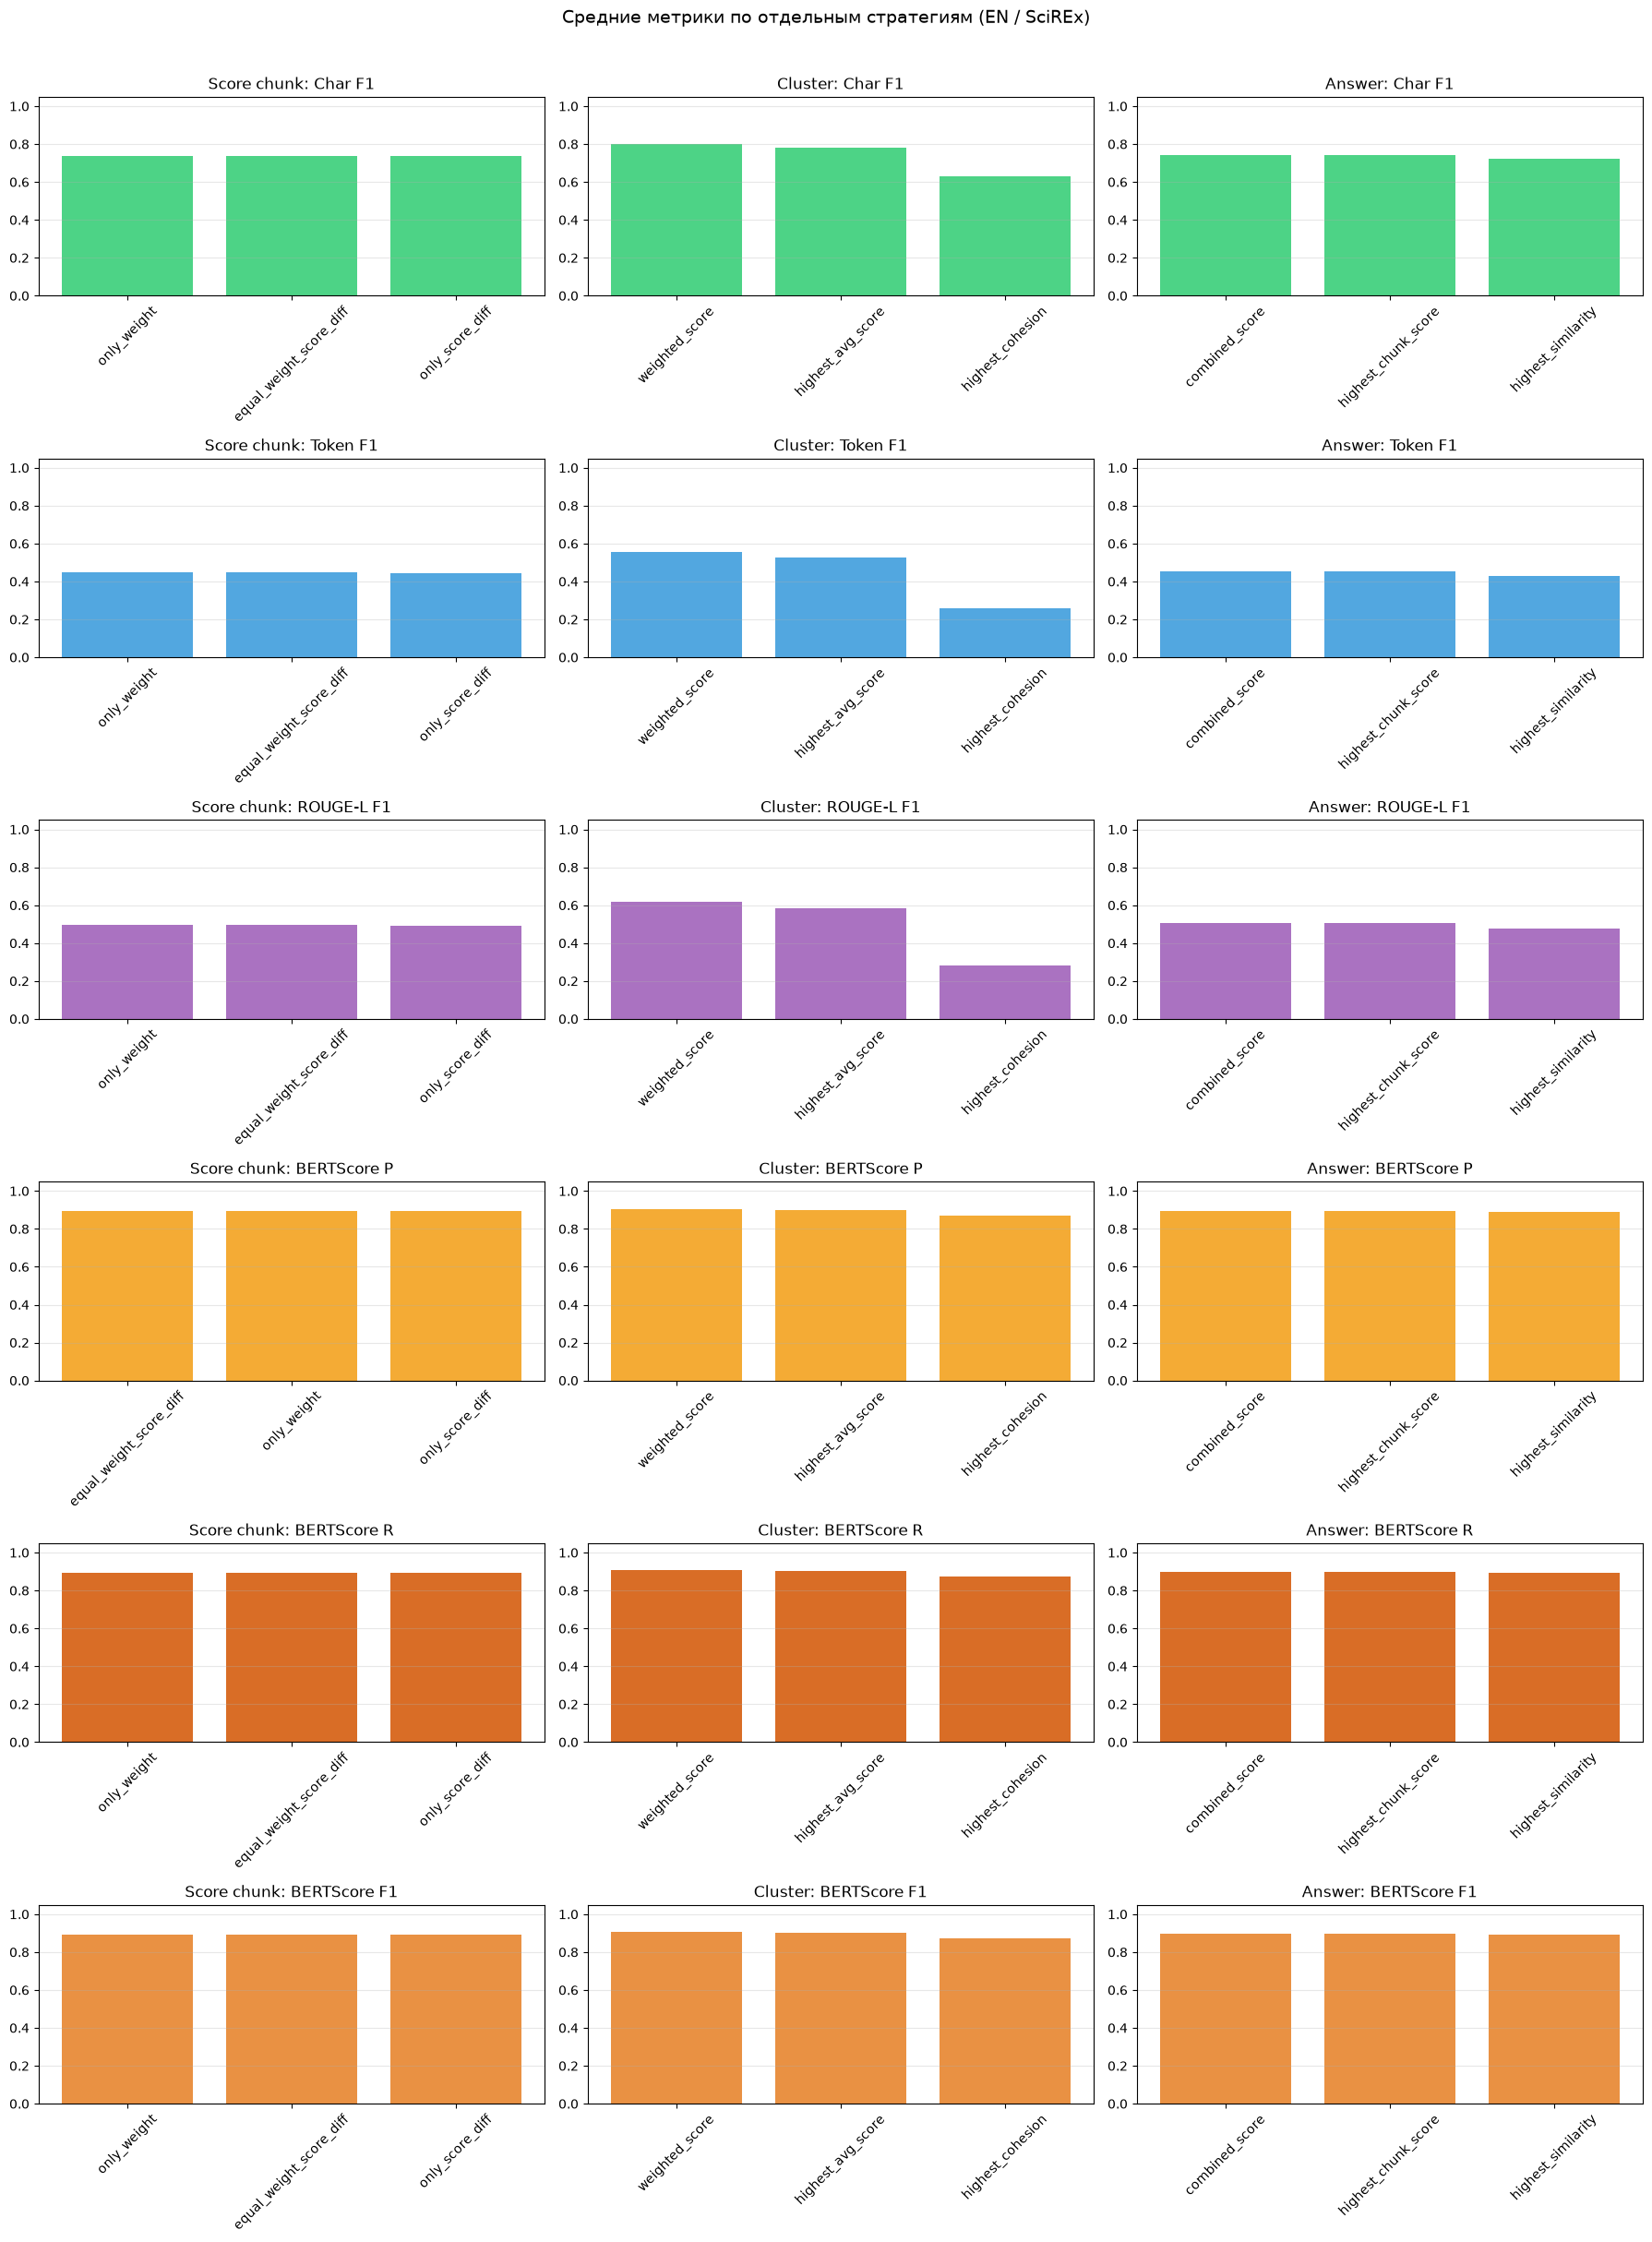

Сохранено: /home/aiserver/POLINA/UnTIE_project/experiments/analysis_results/extraction_metrics/figures/strategy_dimension_bars_en.png


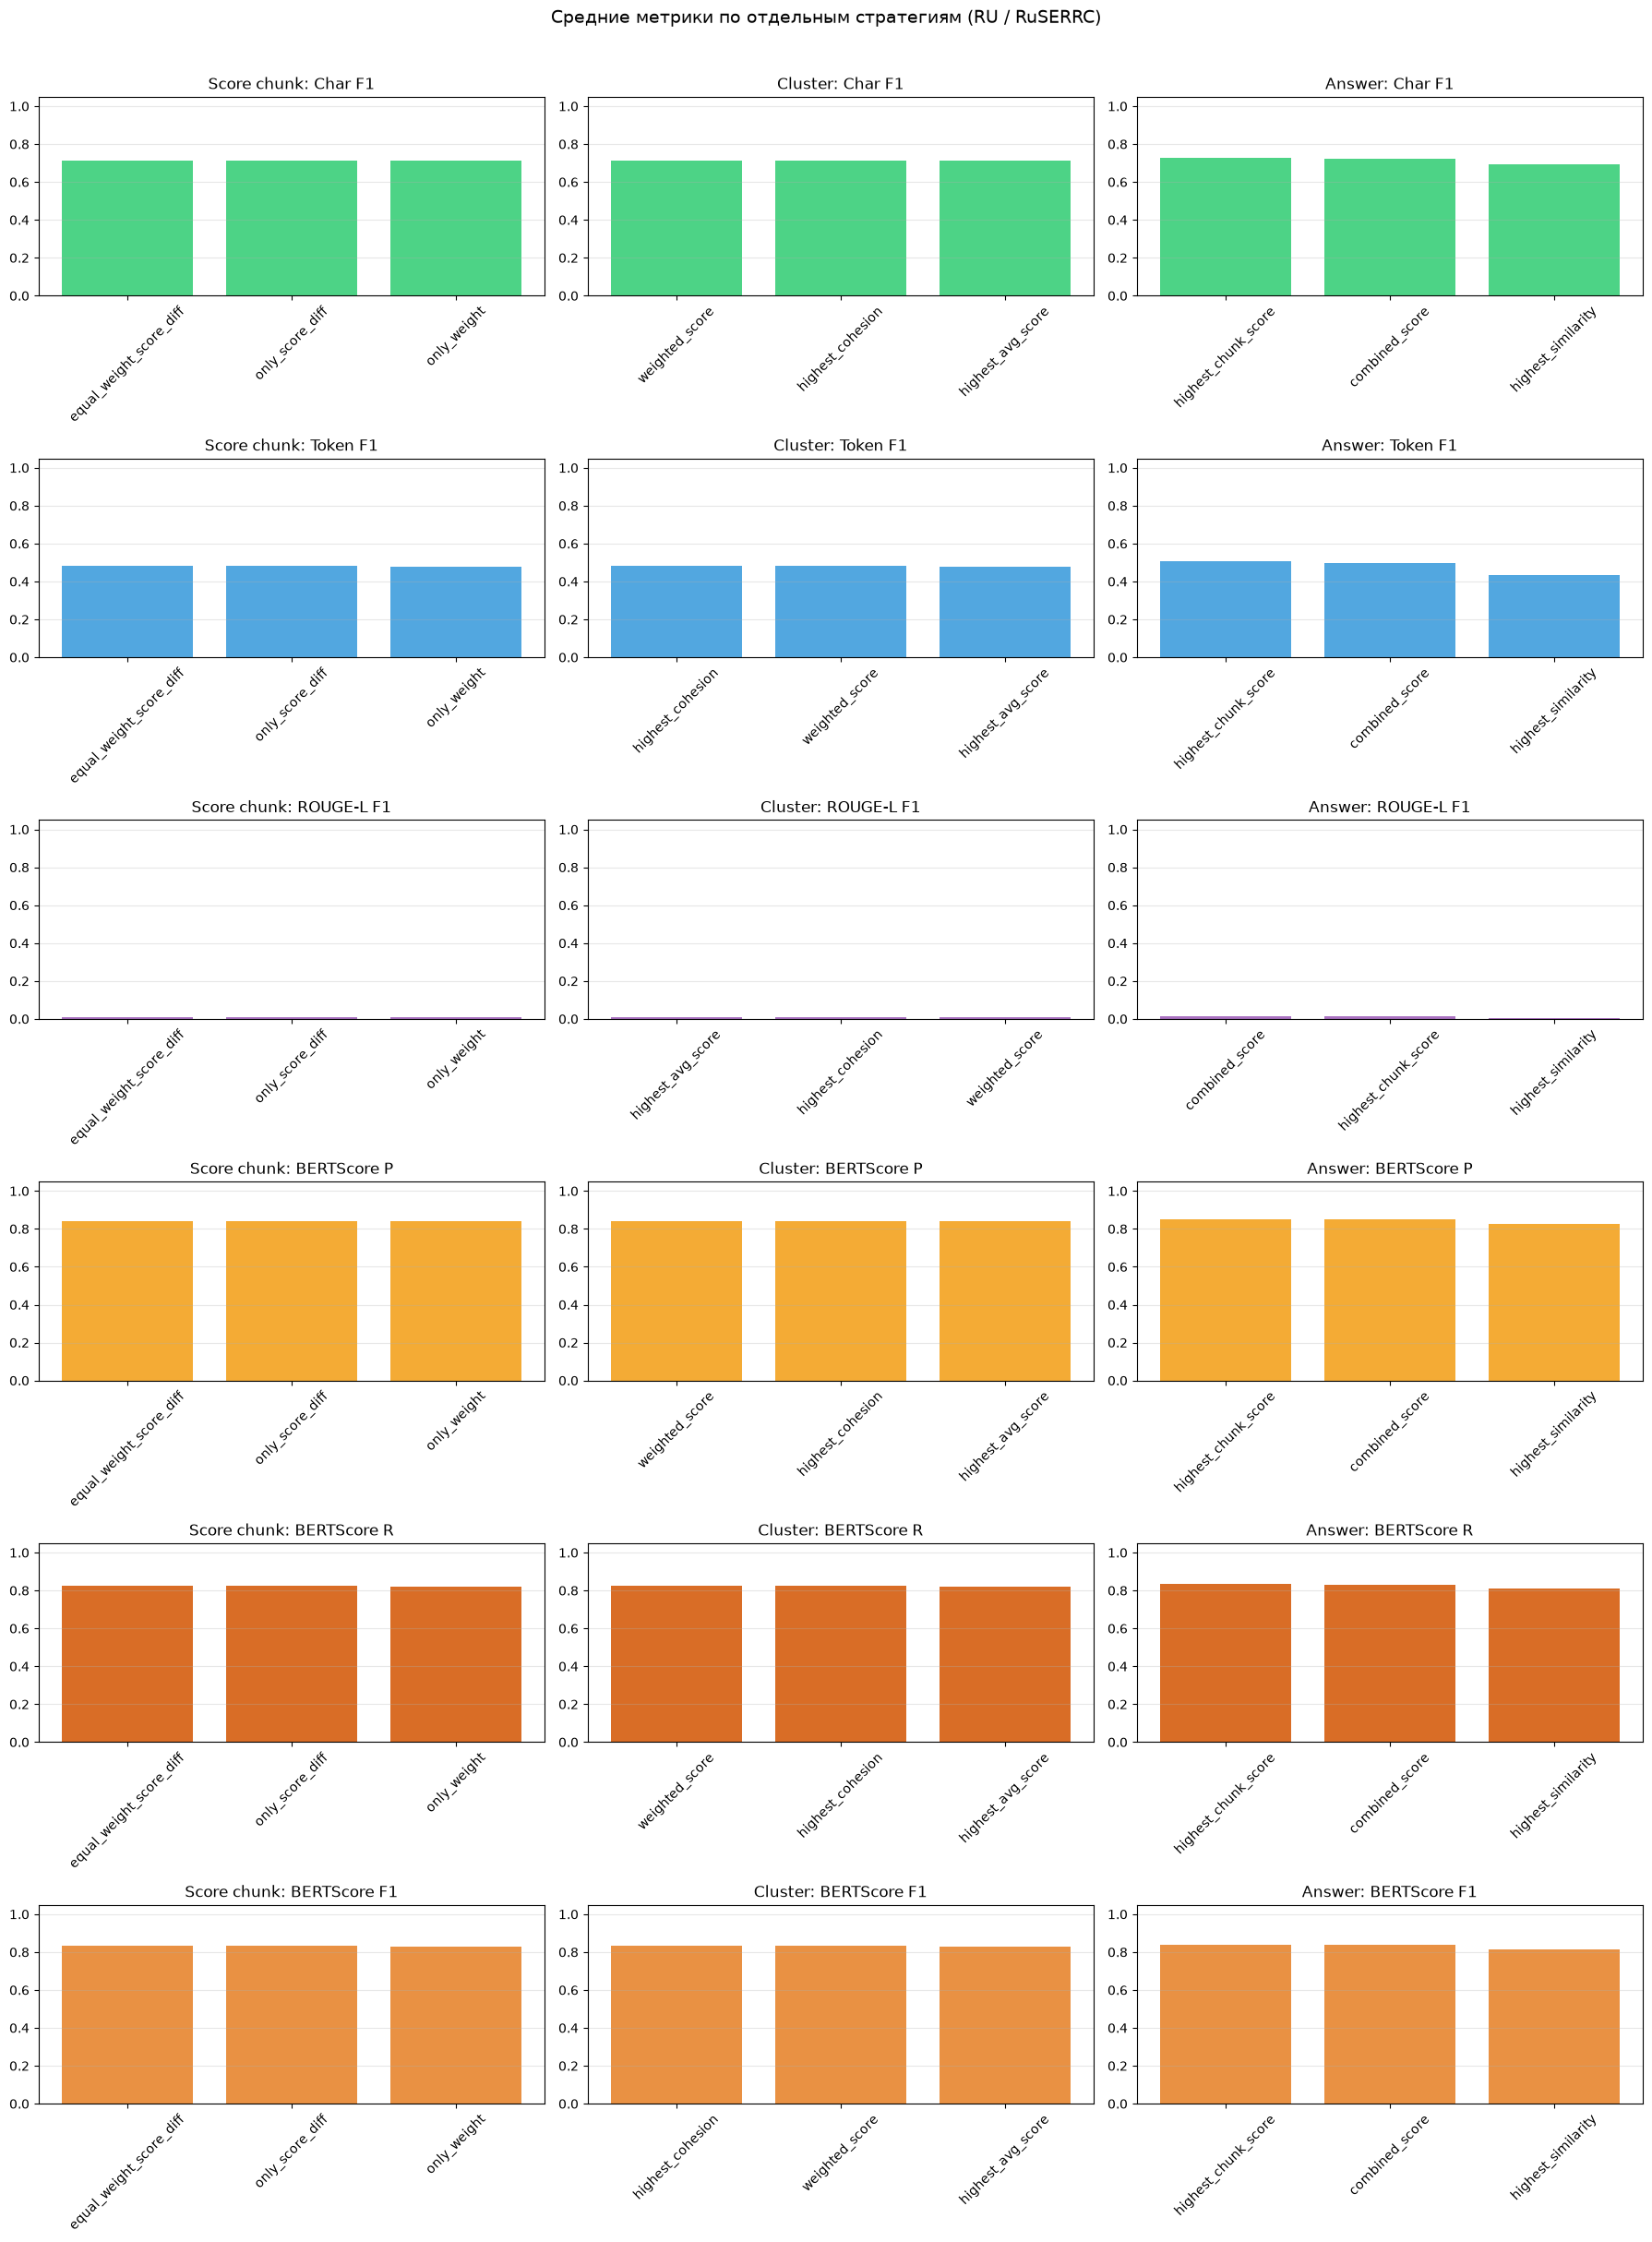

Сохранено: /home/aiserver/POLINA/UnTIE_project/experiments/analysis_results/extraction_metrics/figures/strategy_dimension_bars_ru.png


In [4]:
def plot_metric_bars_by_strategy_dimension(lang: str, r: dict) -> None:
    df = r["scored"]
    fig, axes = plt.subplots(len(PLOT_METRICS), 3, figsize=(18, 4 * len(PLOT_METRICS)))
    if len(PLOT_METRICS) == 1:
        axes = np.array([axes])

    strategy_sets = [
        ("score_chunk_strategy", "Score chunk"),
        ("choose_cluster_strategy", "Cluster"),
        ("choose_answer_strategy", "Answer"),
    ]

    for row_idx, metric in enumerate(PLOT_METRICS):
        for col_idx, (strategy_col, title) in enumerate(strategy_sets):
            ax = axes[row_idx, col_idx]
            stats = aggregate_metric_by_strategy(df, strategy_col, metric)
            values = stats[f"{metric}_mean"].sort_values(ascending=False)
            ax.bar(values.index, values.values, color=COLORS.get(metric, "#34495e"), alpha=0.85)
            ax.set_title(f"{title}: {METRIC_LABELS.get(metric, metric)}")
            ax.set_ylim(0, 1.05)
            ax.tick_params(axis="x", rotation=45)
            ax.grid(True, axis="y", alpha=0.3)

    fig.suptitle(f"Средние метрики по отдельным стратегиям ({r['label']})", fontsize=14, y=1.01)
    fig.tight_layout()
    out = FIGURES_DIR / f"strategy_dimension_bars_{lang}.png"
    fig.savefig(out, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Сохранено: {out}")


for lang, r in results.items():
    plot_metric_bars_by_strategy_dimension(lang, r)


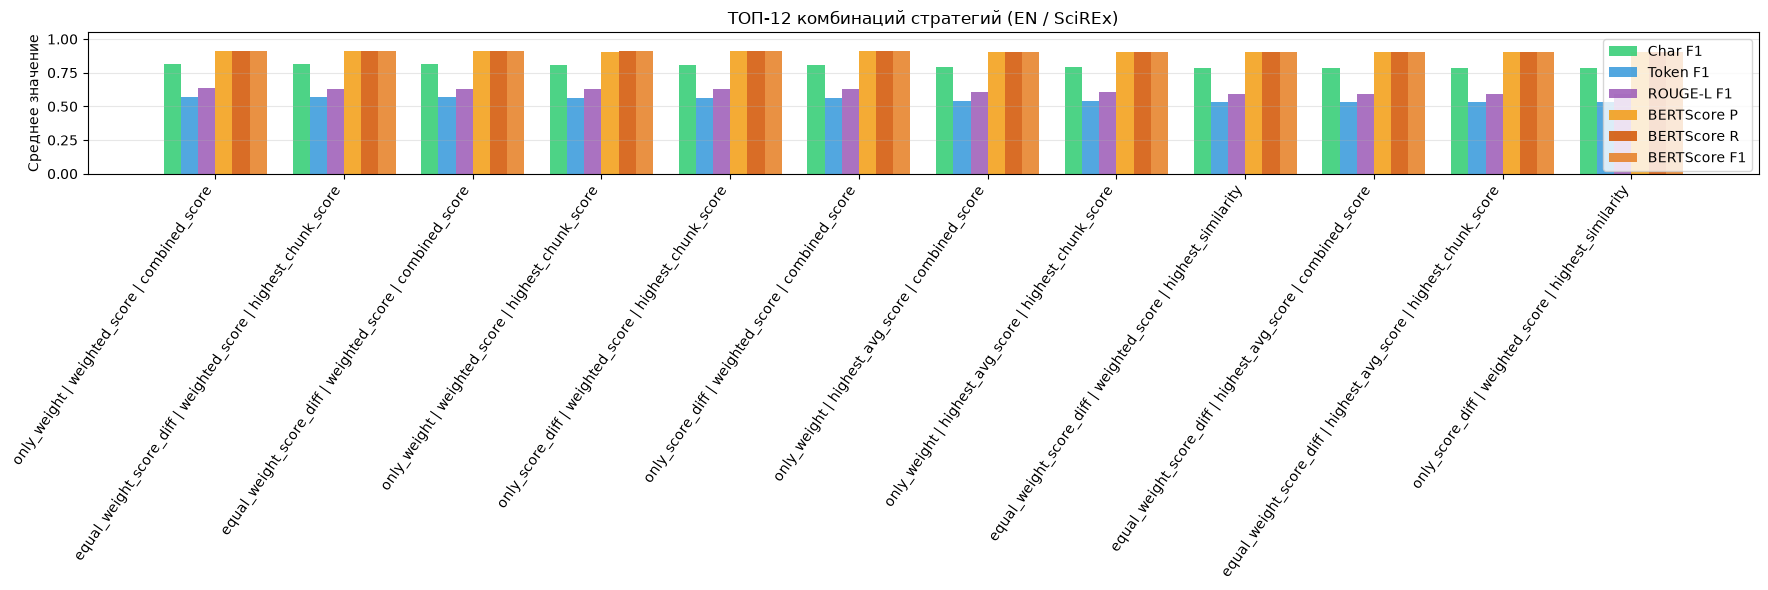

Сохранено: /home/aiserver/POLINA/UnTIE_project/experiments/analysis_results/extraction_metrics/figures/top_strategy_combos_en.png


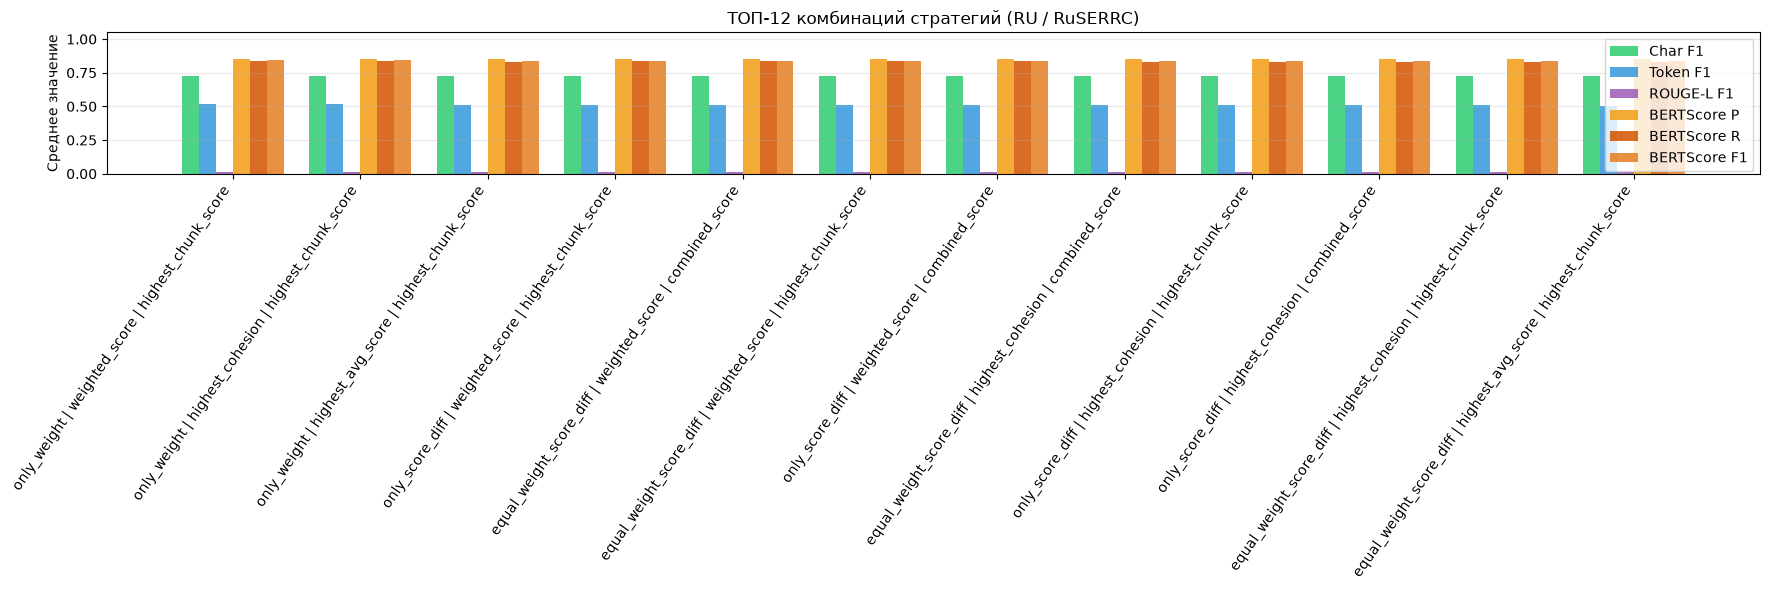

Сохранено: /home/aiserver/POLINA/UnTIE_project/experiments/analysis_results/extraction_metrics/figures/top_strategy_combos_ru.png


In [5]:
def plot_top_strategy_combos(lang: str, r: dict, top_n: int = 12) -> None:
    summary = r["summary"].head(top_n).copy()
    if summary.empty:
        print(f"[{lang}] summary пуст")
        return

    summary = summary.reset_index()
    summary["strategy_combo"] = summary[list(STRATEGY_COLUMNS)].agg(" | ".join, axis=1)

    x = np.arange(len(summary))
    n_metrics = len(PLOT_METRICS)
    width = min(0.8 / max(n_metrics, 1), 0.14)
    fig, ax = plt.subplots(figsize=(18, 6))

    for idx, metric in enumerate(PLOT_METRICS):
        col = summary_metric_column(metric)
        if col not in summary.columns:
            continue
        offset = (idx - (n_metrics - 1) / 2) * width
        ax.bar(x + offset, summary[col], width, label=METRIC_LABELS.get(metric, metric), color=COLORS.get(metric), alpha=0.85)

    ax.set_xticks(x)
    ax.set_xticklabels(summary["strategy_combo"], rotation=55, ha="right")
    ax.set_ylim(0, 1.05)
    ax.set_ylabel("Среднее значение")
    ax.set_title(f"ТОП-{top_n} комбинаций стратегий ({r['label']})")
    ax.legend()
    ax.grid(True, axis="y", alpha=0.3)
    fig.tight_layout()
    out = FIGURES_DIR / f"top_strategy_combos_{lang}.png"
    fig.savefig(out, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Сохранено: {out}")


for lang, r in results.items():
    plot_top_strategy_combos(lang, r)


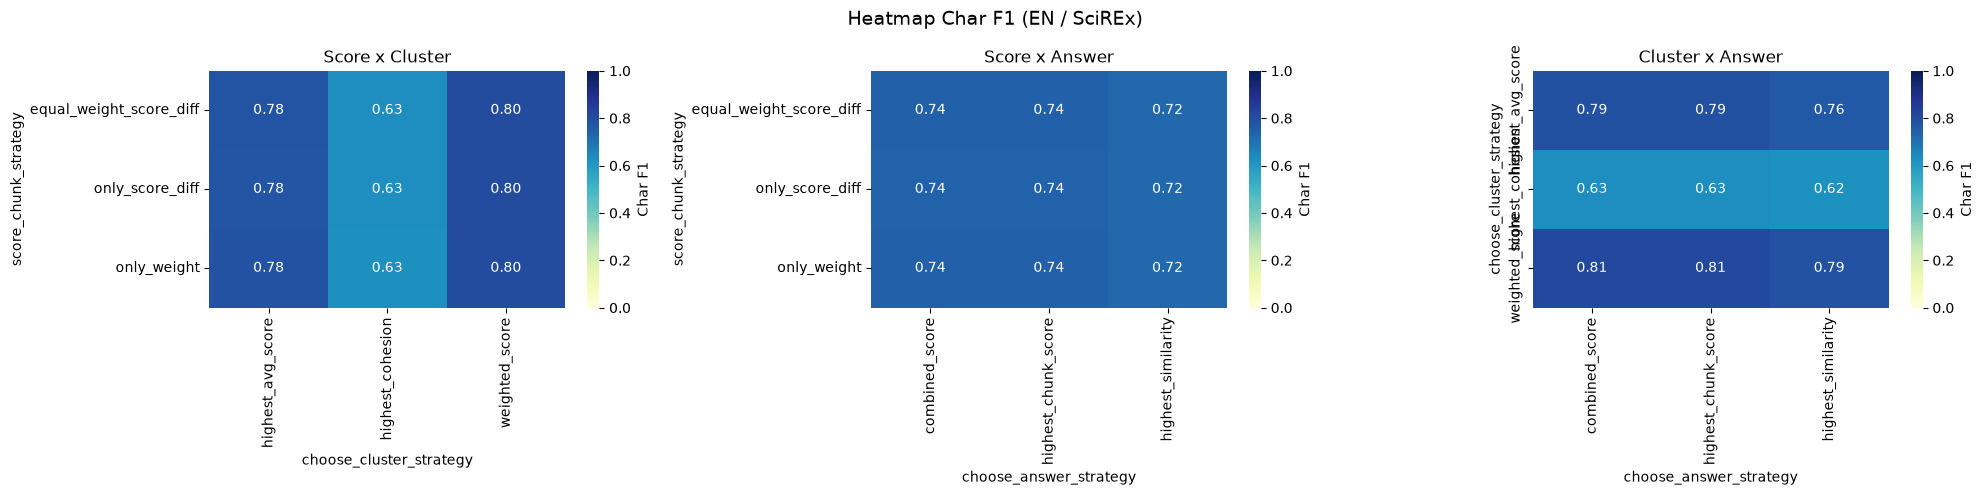

Сохранено: /home/aiserver/POLINA/UnTIE_project/experiments/analysis_results/extraction_metrics/figures/heatmap_char_f1_en.png


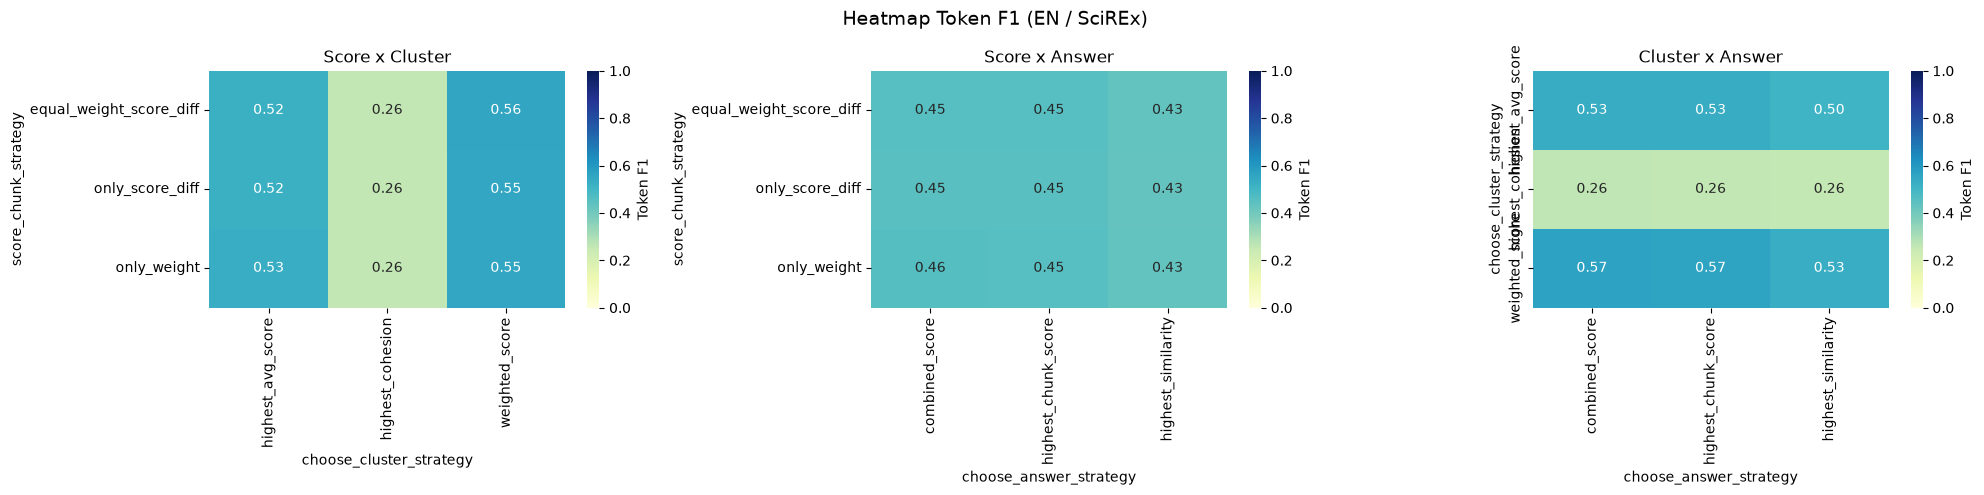

Сохранено: /home/aiserver/POLINA/UnTIE_project/experiments/analysis_results/extraction_metrics/figures/heatmap_token_f1_norm_en.png


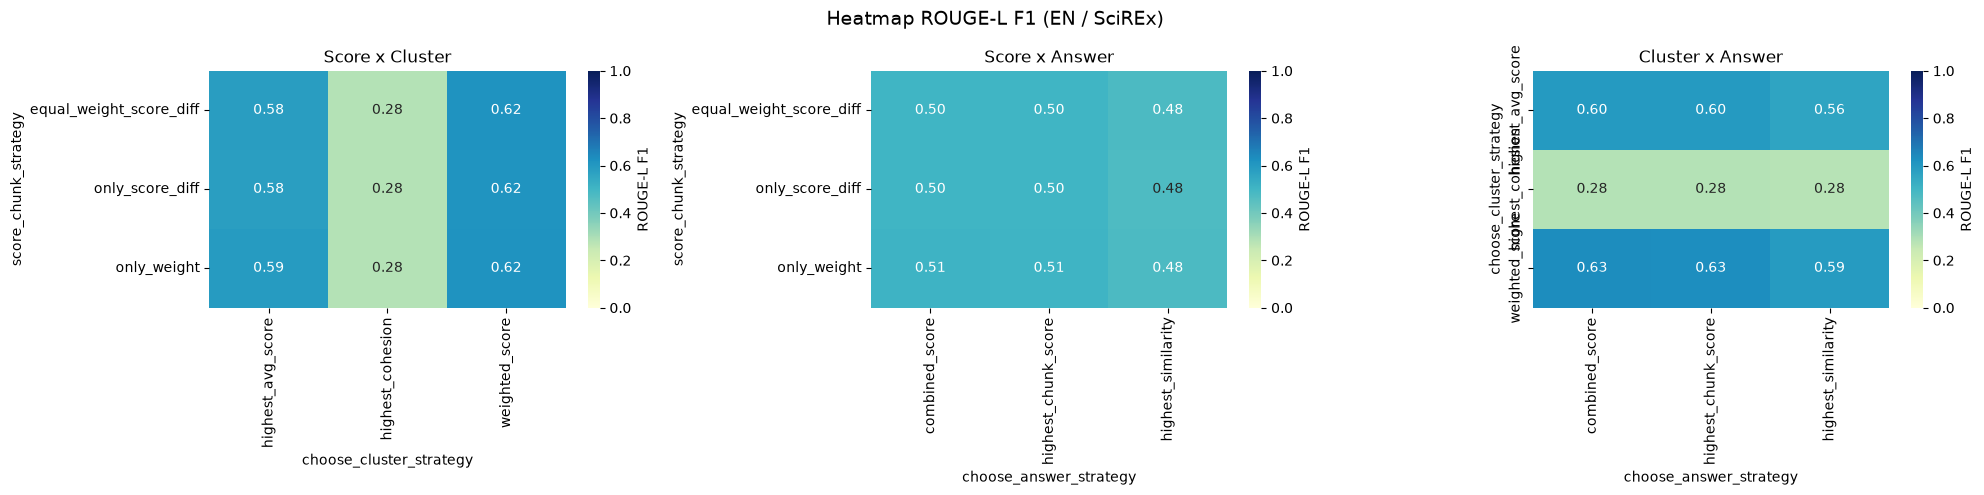

Сохранено: /home/aiserver/POLINA/UnTIE_project/experiments/analysis_results/extraction_metrics/figures/heatmap_rouge_l_f1_en.png


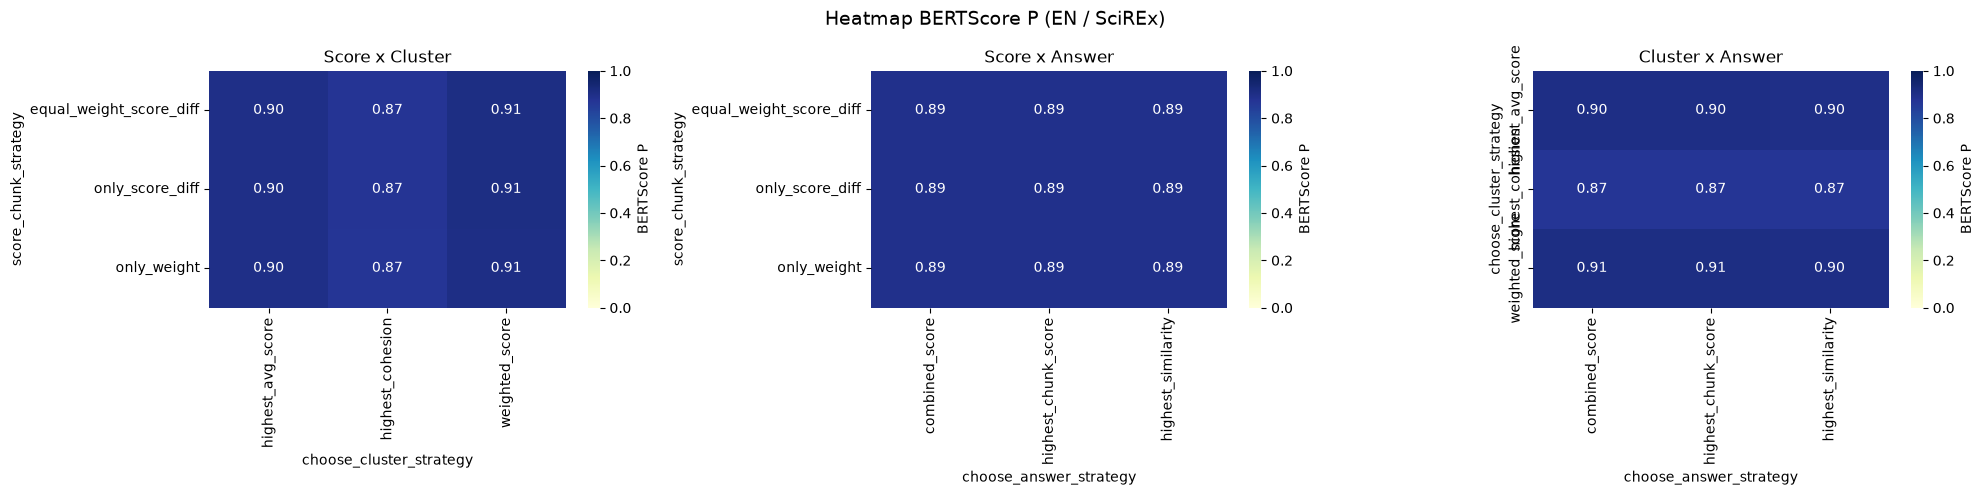

Сохранено: /home/aiserver/POLINA/UnTIE_project/experiments/analysis_results/extraction_metrics/figures/heatmap_bertscore_p_en.png


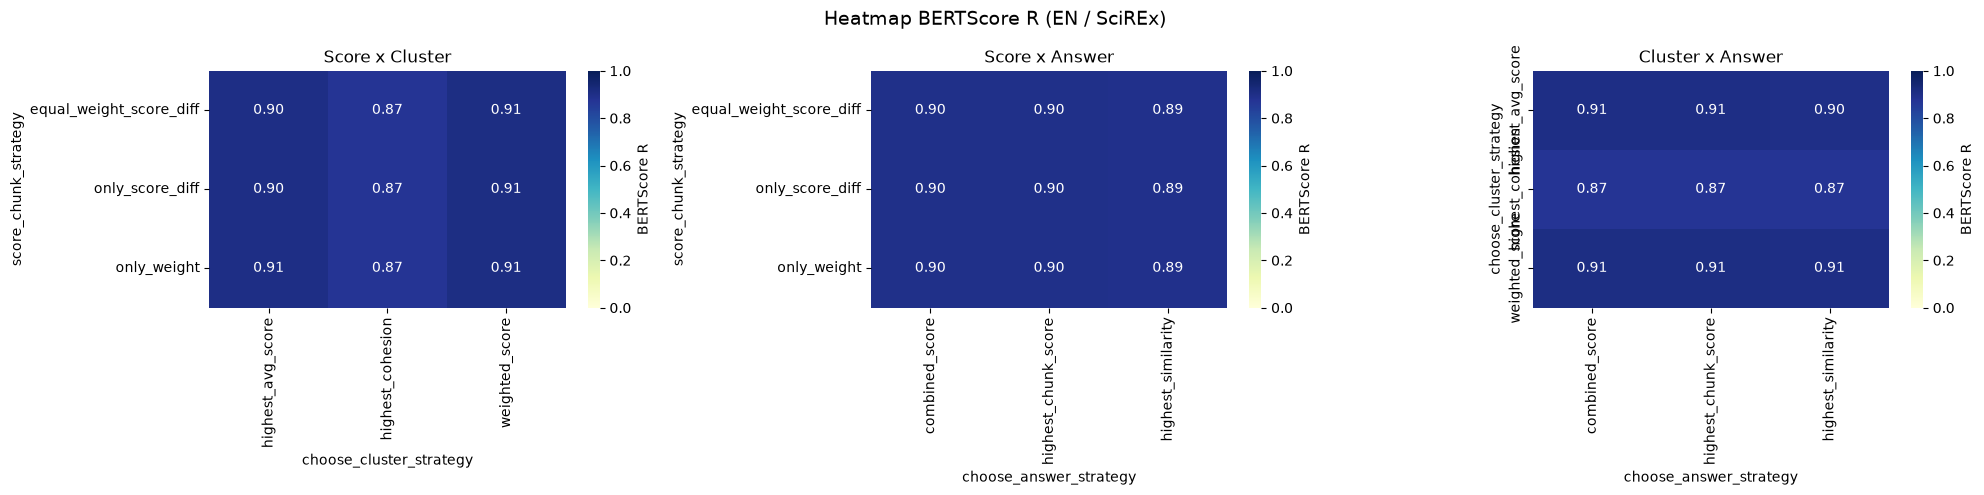

Сохранено: /home/aiserver/POLINA/UnTIE_project/experiments/analysis_results/extraction_metrics/figures/heatmap_bertscore_r_en.png


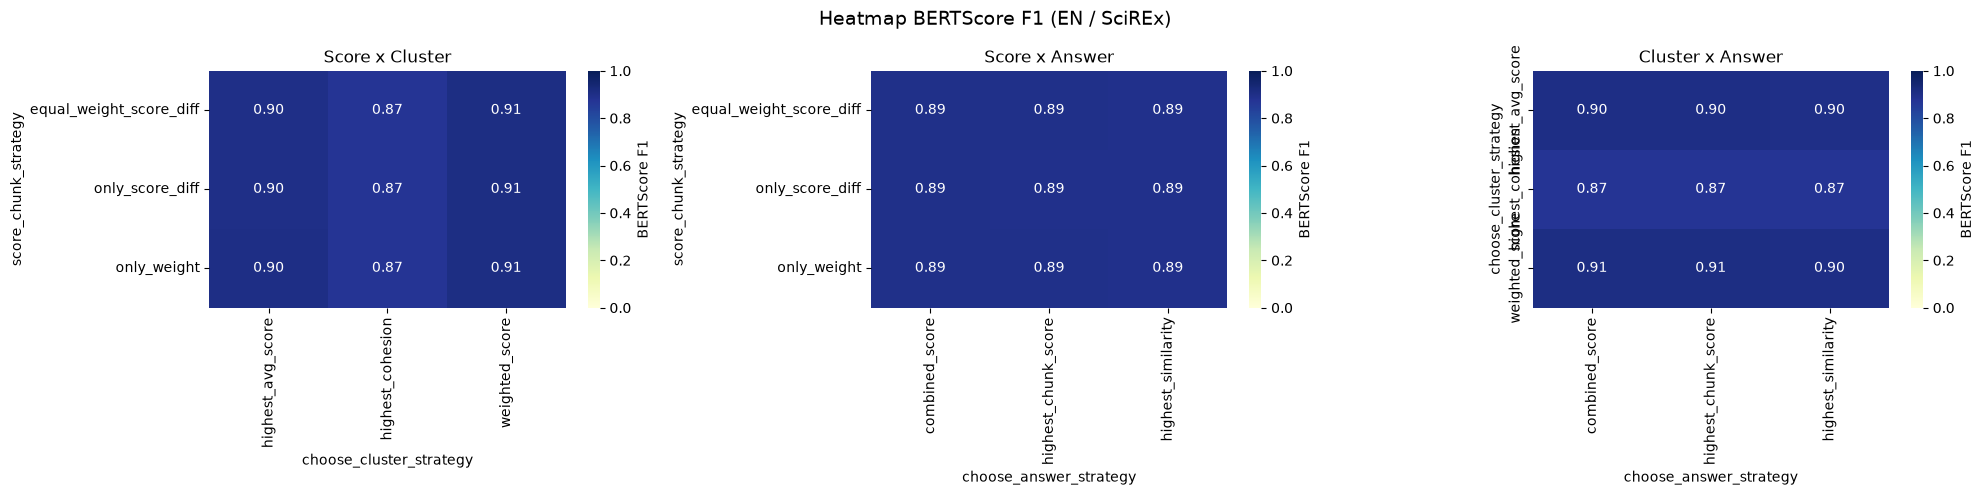

Сохранено: /home/aiserver/POLINA/UnTIE_project/experiments/analysis_results/extraction_metrics/figures/heatmap_bertscore_f1_en.png


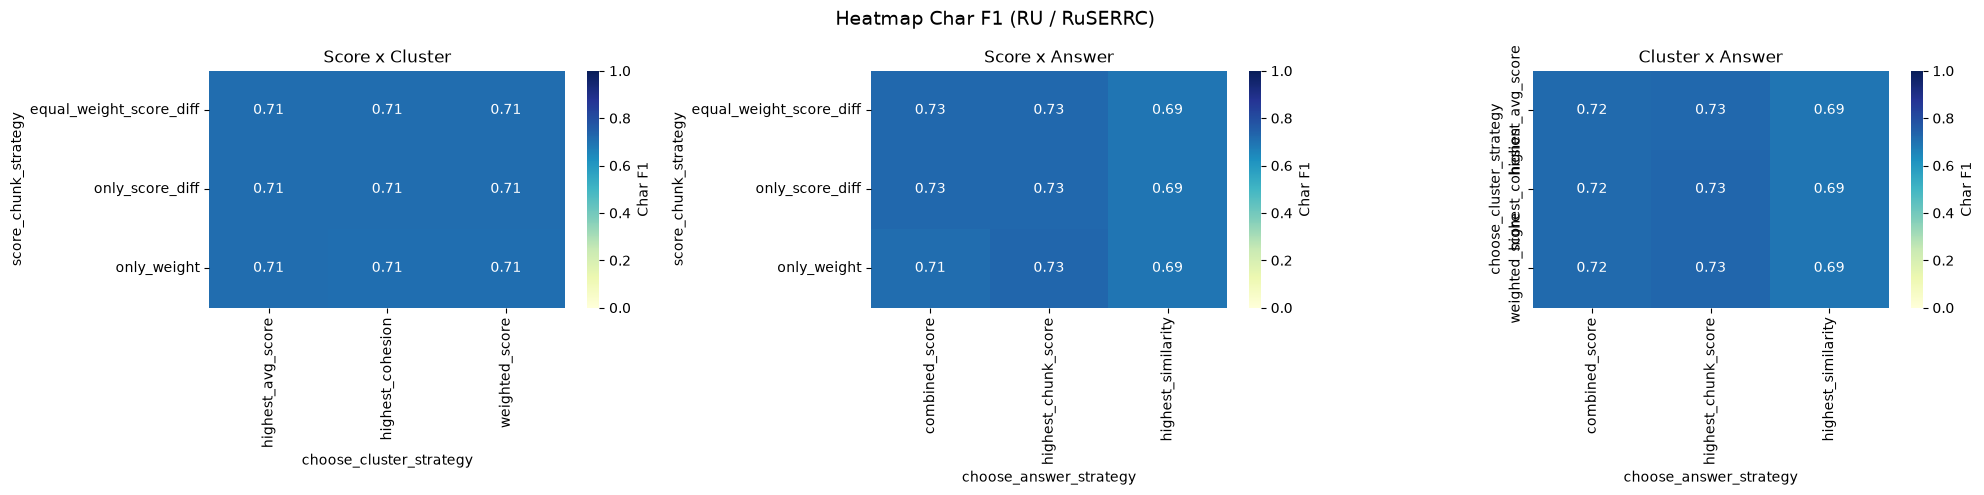

Сохранено: /home/aiserver/POLINA/UnTIE_project/experiments/analysis_results/extraction_metrics/figures/heatmap_char_f1_ru.png


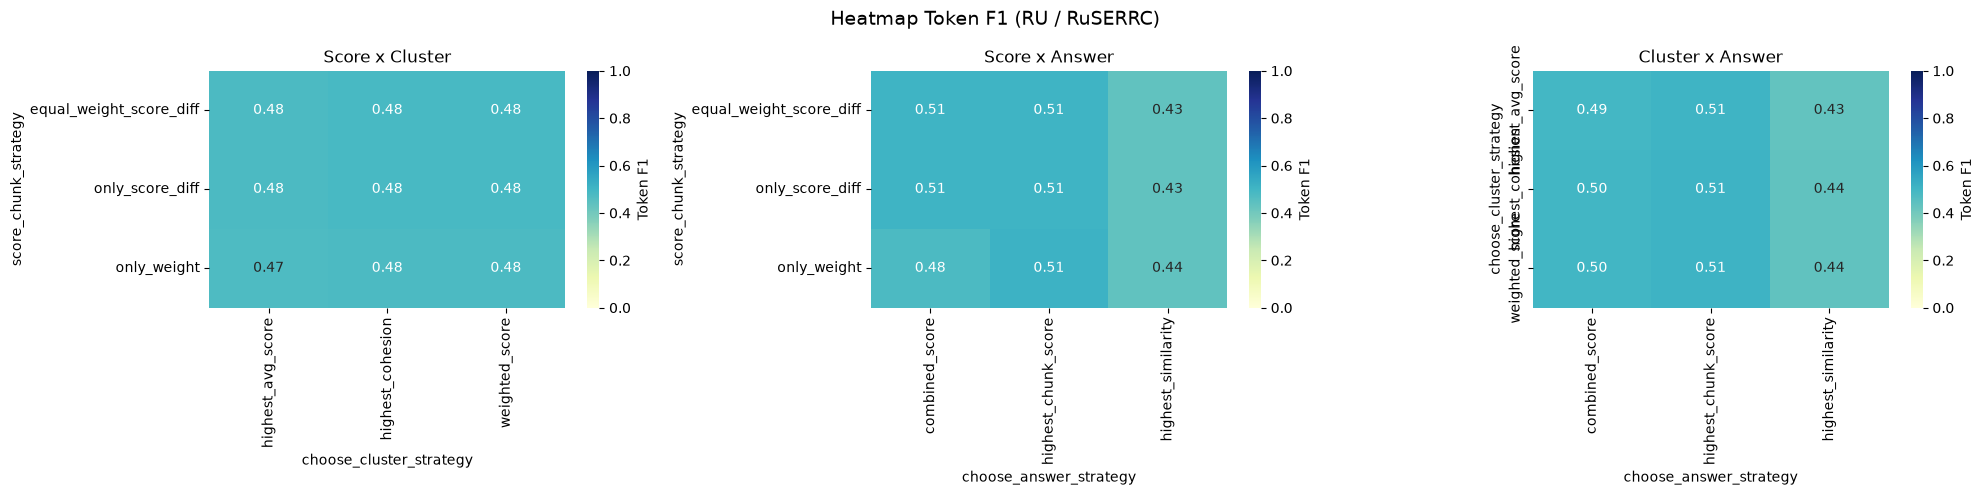

Сохранено: /home/aiserver/POLINA/UnTIE_project/experiments/analysis_results/extraction_metrics/figures/heatmap_token_f1_norm_ru.png


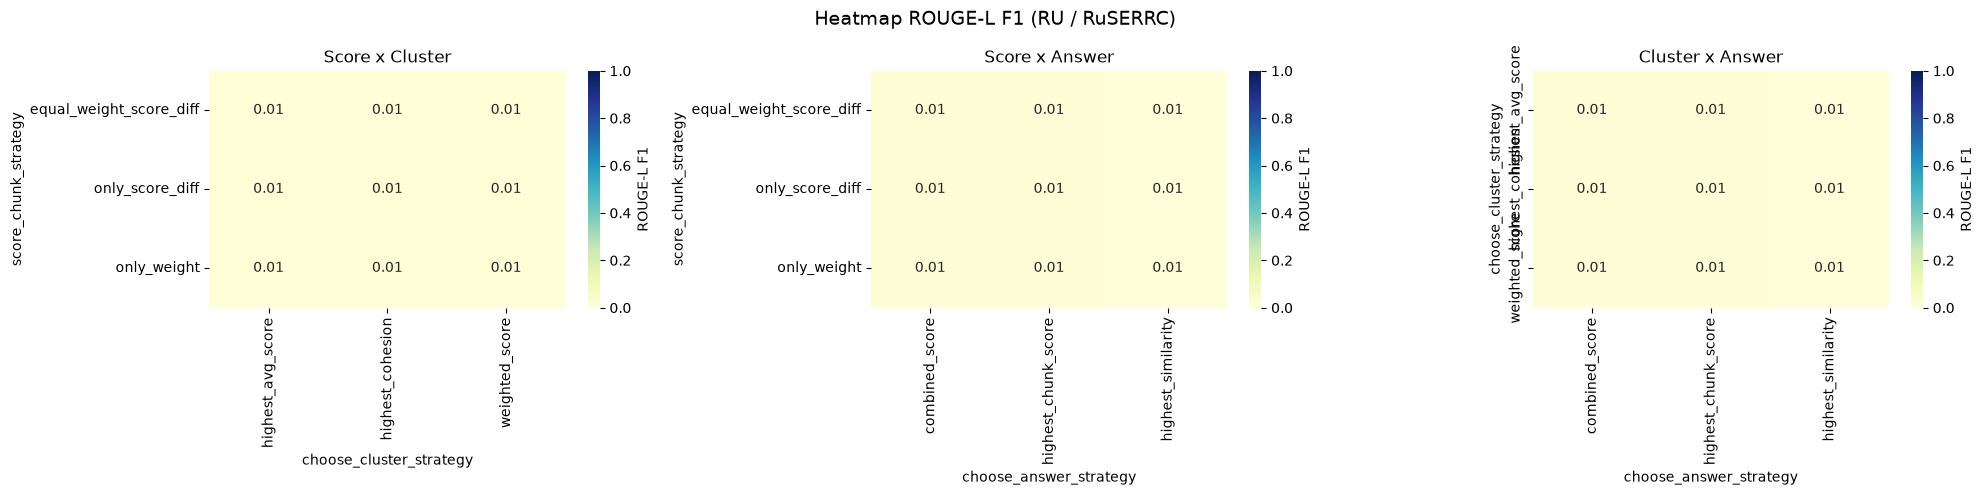

Сохранено: /home/aiserver/POLINA/UnTIE_project/experiments/analysis_results/extraction_metrics/figures/heatmap_rouge_l_f1_ru.png


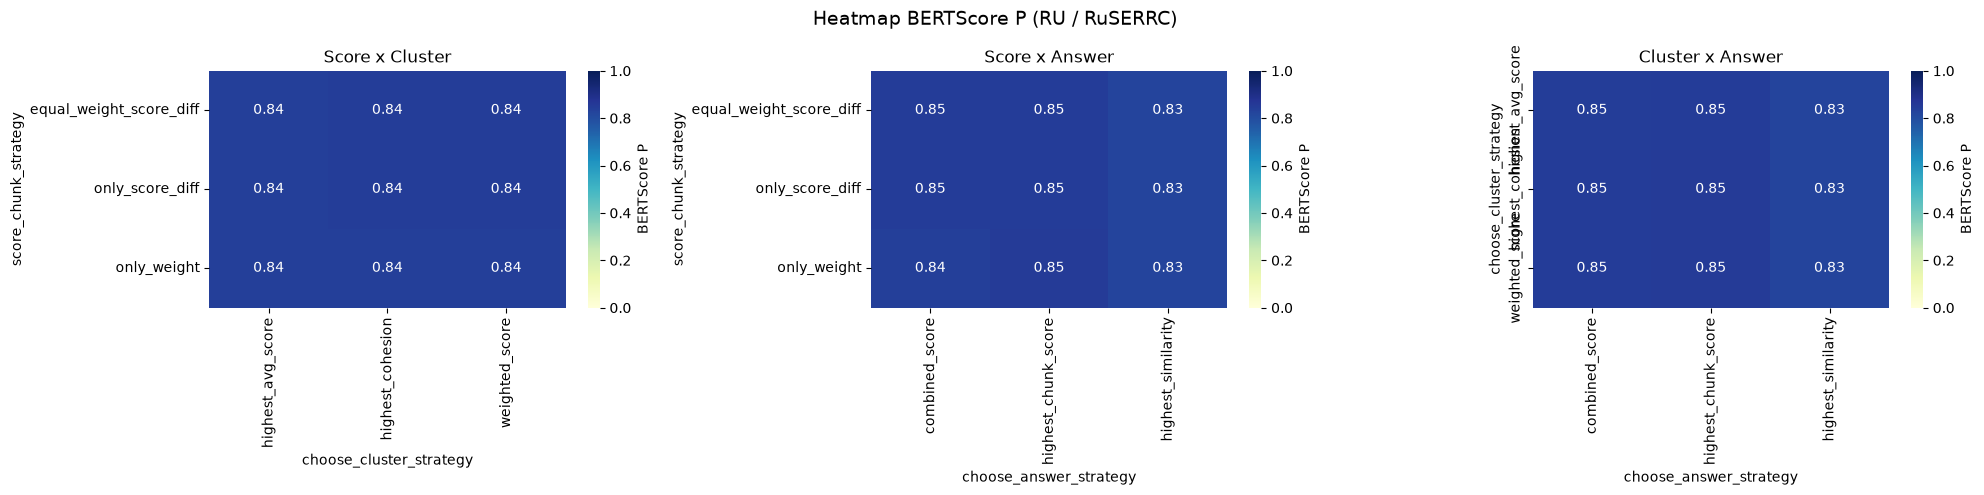

Сохранено: /home/aiserver/POLINA/UnTIE_project/experiments/analysis_results/extraction_metrics/figures/heatmap_bertscore_p_ru.png


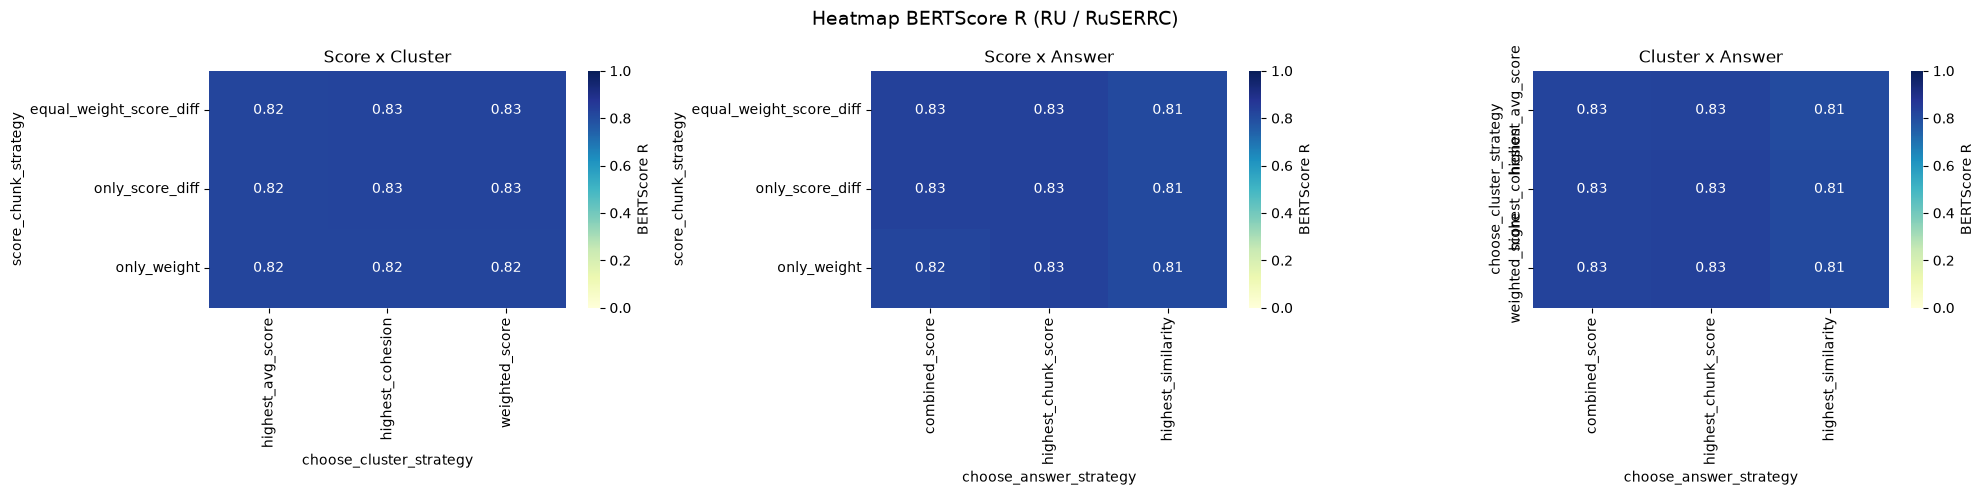

Сохранено: /home/aiserver/POLINA/UnTIE_project/experiments/analysis_results/extraction_metrics/figures/heatmap_bertscore_r_ru.png


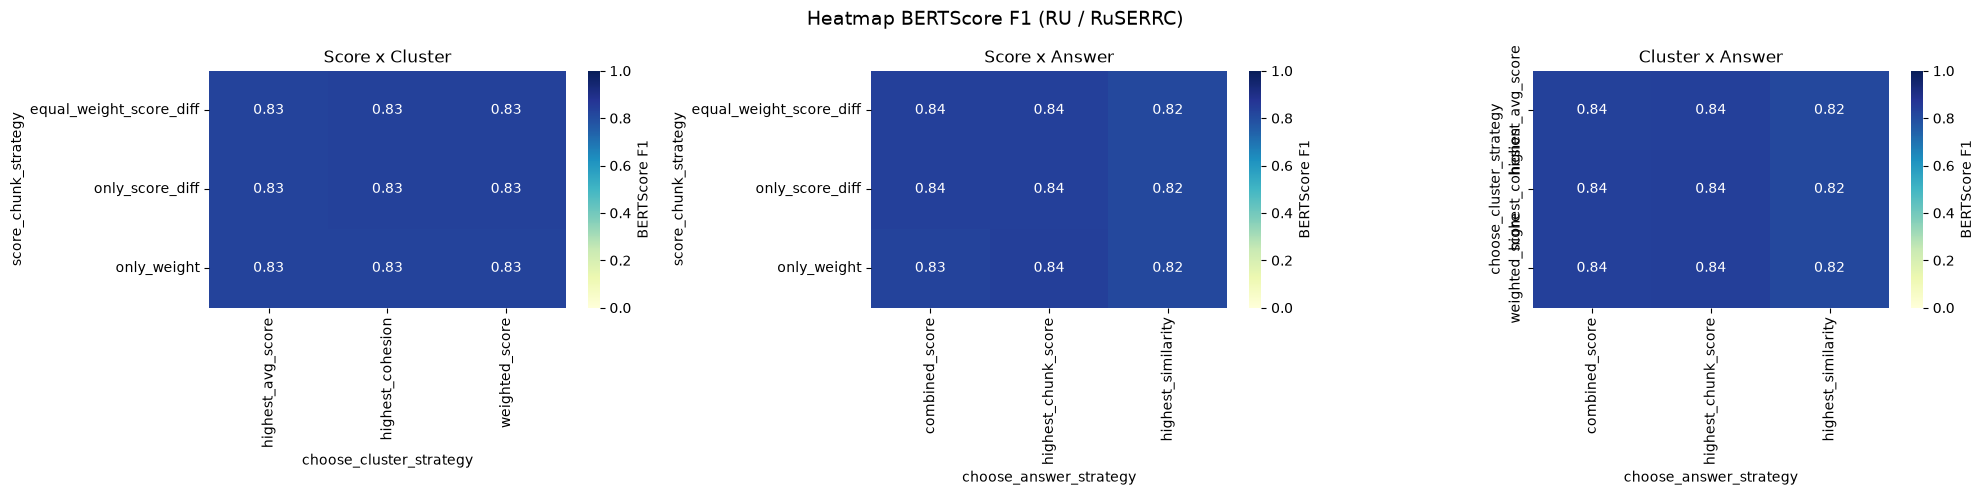

Сохранено: /home/aiserver/POLINA/UnTIE_project/experiments/analysis_results/extraction_metrics/figures/heatmap_bertscore_f1_ru.png


In [6]:
def plot_metric_heatmaps(lang: str, r: dict, metric: str = "rouge_l_f1") -> None:
    if not HAS_SEABORN:
        print("Seaborn не установлен — heatmap пропущены")
        return

    df = r["scored"]
    value_col = metric.replace("_norm", "") if metric.endswith("_norm") else metric
    if value_col not in df.columns:
        print(f"Колонка {value_col} не найдена")
        return

    work = df.copy()
    if metric == "token_f1_norm":
        work["plot_value"] = work["token_f1"] / 100.0
    else:
        work["plot_value"] = work[value_col]

    fig, axes = plt.subplots(1, 3, figsize=(20, 5))
    pairs = [
        ("score_chunk_strategy", "choose_cluster_strategy", "Score x Cluster"),
        ("score_chunk_strategy", "choose_answer_strategy", "Score x Answer"),
        ("choose_cluster_strategy", "choose_answer_strategy", "Cluster x Answer"),
    ]

    for ax, (row_col, col_col, title) in zip(axes, pairs):
        pivot = work.groupby([row_col, col_col])["plot_value"].mean().unstack()
        sns.heatmap(
            pivot,
            annot=True,
            fmt=".2f",
            cmap="YlGnBu",
            vmin=0,
            vmax=1,
            cbar_kws={"label": METRIC_LABELS.get(metric, metric)},
            ax=ax,
        )
        ax.set_title(title)

    fig.suptitle(f"Heatmap {METRIC_LABELS.get(metric, metric)} ({r['label']})", fontsize=14)
    fig.tight_layout()
    out = FIGURES_DIR / f"heatmap_{metric}_{lang}.png"
    fig.savefig(out, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Сохранено: {out}")


for lang, r in results.items():
    for metric in PLOT_METRICS:
        plot_metric_heatmaps(lang, r, metric=metric)


In [7]:
for lang, r in results.items():
    display_cols = resolve_display_cols(r["summary"])
    print(f"\n{'=' * 72}")
    print(f"ТОП-5 комбинаций ({r['label']}) по composite_extraction")
    print('=' * 72)
    display(r["summary"][display_cols].head())

    if not r["evaluable_summary"].empty:
        print(f"\nТОП-5 evaluable ({r['label']})")
        display(r["evaluable_summary"][resolve_display_cols(r["evaluable_summary"])].head())
    else:
        print("\nEvaluable-подмножество пусто или отсутствует.")



ТОП-5 комбинаций (EN / SciREx) по composite_extraction


char_f1_mean  \
score_chunk_strategy    choose_cluster_strategy choose_answer_strategy                 
only_weight             weighted_score          combined_score              0.813554   
equal_weight_score_diff weighted_score          highest_chunk_score         0.812692   
                                                combined_score              0.812692   
only_weight             weighted_score          highest_chunk_score         0.810428   
only_score_diff         weighted_score          highest_chunk_score         0.810095   

                                                                        token_f1_norm_mean  \
score_chunk_strategy    choose_cluster_strategy choose_answer_strategy                       
only_weight             weighted_score          combined_score                    0.568734   
equal_weight_score_diff weighted_score          highest_chunk_score               0.568203   
                                                combined_score                    0.568203   
only_weight             weighted_score          highest_chunk_score               0.564717   
only_score_diff         weighted_score          highest_chunk_score               0.564566   

                                                                        rouge_l_f1_mean  \
score_chunk_strategy    choose_cluster_strategy choose_answer_strategy                    
only_weight             weighted_score          combined_score                 0.636757   
equal_weight_score_diff weighted_score          highest_chunk_score            0.632835   
                                                combined_score                 0.632835   
only_weight             weighted_score          highest_chunk_score            0.632610   
only_score_diff         weighted_score          highest_chunk_score            0.629198   

                                                                        bertscore_p_mean  \
score_chunk_strategy    choose_cluster_strategy choose_answer_strategy                     
only_weight             weighted_score          combined_score                  0.907698   
equal_weight_score_diff weighted_score          highest_chunk_score             0.908199   
                                                combined_score                  0.908199   
only_weight             weighted_score          highest_chunk_score             0.907488   
only_score_diff         weighted_score          highest_chunk_score             0.907744   

                                                                        bertscore_r_mean  \
score_chunk_strategy    choose_cluster_strategy choose_answer_strategy                     
only_weight             weighted_score          combined_score                  0.909137   
equal_weight_score_diff weighted_score          highest_chunk_score             0.909756   
                                                combined_score                  0.909756   
only_weight             weighted_score          highest_chunk_score             0.908973   
only_score_diff         weighted_score          highest_chunk_score             0.909435   

                                                                        bertscore_f1_mean  \
score_chunk_strategy    choose_cluster_strategy choose_answer_strategy                      
only_weight             weighted_score          combined_score                   0.908216   
equal_weight_score_diff weighted_score          highest_chunk_score              0.908780   
                                                combined_score                   0.908780   
only_weight             weighted_score          highest_chunk_score              0.908029   
only_score_diff         weighted_score          highest_chunk_score              0.908391   

                                                                        composite_extraction  \
score_chunk_strategy    choose_cluster_strategy choose_answer_strategy                         
only_weight             


Evaluable-подмножество пусто или отсутствует.

ТОП-5 комбинаций (RU / RuSERRC) по composite_extraction


char_f1_mean  \
score_chunk_strategy    choose_cluster_strategy choose_answer_strategy                 
only_weight             weighted_score          highest_chunk_score         0.728038   
                        highest_cohesion        highest_chunk_score         0.727975   
                        highest_avg_score       highest_chunk_score         0.728256   
only_score_diff         weighted_score          highest_chunk_score         0.726236   
equal_weight_score_diff weighted_score          combined_score              0.726236   

                                                                        token_f1_norm_mean  \
score_chunk_strategy    choose_cluster_strategy choose_answer_strategy                       
only_weight             weighted_score          highest_chunk_score               0.514691   
                        highest_cohesion        highest_chunk_score               0.514691   
                        highest_avg_score       highest_chunk_score               0.510417   
only_score_diff         weighted_score          highest_chunk_score               0.508993   
equal_weight_score_diff weighted_score          combined_score                    0.508993   

                                                                        rouge_l_f1_mean  \
score_chunk_strategy    choose_cluster_strategy choose_answer_strategy                    
only_weight             weighted_score          highest_chunk_score            0.012821   
                        highest_cohesion        highest_chunk_score            0.012821   
                        highest_avg_score       highest_chunk_score            0.012821   
only_score_diff         weighted_score          highest_chunk_score            0.012821   
equal_weight_score_diff weighted_score          combined_score                 0.012821   

                                                                        bertscore_p_mean  \
score_chunk_strategy    choose_cluster_strategy choose_answer_strategy                     
only_weight             weighted_score          highest_chunk_score             0.853378   
                        highest_cohesion        highest_chunk_score             0.853328   
                        highest_avg_score       highest_chunk_score             0.852385   
only_score_diff         weighted_score          highest_chunk_score             0.852112   
equal_weight_score_diff weighted_score          combined_score                  0.852112   

                                                                        bertscore_r_mean  \
score_chunk_strategy    choose_cluster_strategy choose_answer_strategy                     
only_weight             weighted_score          highest_chunk_score             0.834909   
                        highest_cohesion        highest_chunk_score             0.834872   
                        highest_avg_score       highest_chunk_score             0.833369   
only_score_diff         weighted_score          highest_chunk_score             0.833430   
equal_weight_score_diff weighted_score          combined_score                  0.833430   

                                                                        bertscore_f1_mean  \
score_chunk_strategy    choose_cluster_strategy choose_answer_strategy                      
only_weight             weighted_score          highest_chunk_score              0.841808   
                        highest_cohesion        highest_chunk_score              0.841765   
                        highest_avg_score       highest_chunk_score              0.840551   
only_score_diff         weighted_score          highest_chunk_score              0.840439   
equal_weight_score_diff weighted_score          combined_score                   0.840439   

                                                                        composite_extraction  \
score_chunk_strategy    choose_cluster_strategy choose_answer_strategy                         
only_weight             


ТОП-5 evaluable (RU / RuSERRC)


char_f1_mean  \
score_chunk_strategy    choose_cluster_strategy choose_answer_strategy                 
only_weight             weighted_score          highest_chunk_score         0.721782   
                        highest_cohesion        highest_chunk_score         0.721705   
                        highest_avg_score       highest_chunk_score         0.722048   
only_score_diff         weighted_score          highest_chunk_score         0.719586   
equal_weight_score_diff weighted_score          combined_score              0.719586   

                                                                        token_f1_norm_mean  \
score_chunk_strategy    choose_cluster_strategy choose_answer_strategy                       
only_weight             weighted_score          highest_chunk_score               0.509874   
                        highest_cohesion        highest_chunk_score               0.509874   
                        highest_avg_score       highest_chunk_score               0.504666   
only_score_diff         weighted_score          highest_chunk_score               0.502930   
equal_weight_score_diff weighted_score          combined_score                    0.502930   

                                                                        rouge_l_f1_mean  \
score_chunk_strategy    choose_cluster_strategy choose_answer_strategy                    
only_weight             weighted_score          highest_chunk_score            0.015625   
                        highest_cohesion        highest_chunk_score            0.015625   
                        highest_avg_score       highest_chunk_score            0.015625   
only_score_diff         weighted_score          highest_chunk_score            0.015625   
equal_weight_score_diff weighted_score          combined_score                 0.015625   

                                                                        bertscore_p_mean  \
score_chunk_strategy    choose_cluster_strategy choose_answer_strategy                     
only_weight             weighted_score          highest_chunk_score             0.852644   
                        highest_cohesion        highest_chunk_score             0.852584   
                        highest_avg_score       highest_chunk_score             0.851434   
only_score_diff         weighted_score          highest_chunk_score             0.851101   
equal_weight_score_diff weighted_score          combined_score                  0.851101   

                                                                        bertscore_r_mean  \
score_chunk_strategy    choose_cluster_strategy choose_answer_strategy                     
only_weight             weighted_score          highest_chunk_score             0.832317   
                        highest_cohesion        highest_chunk_score             0.832272   
                        highest_avg_score       highest_chunk_score             0.830441   
only_score_diff         weighted_score          highest_chunk_score             0.830515   
equal_weight_score_diff weighted_score          combined_score                  0.830515   

                                                                        bertscore_f1_mean  \
score_chunk_strategy    choose_cluster_strategy choose_answer_strategy                      
only_weight             weighted_score          highest_chunk_score              0.839927   
                        highest_cohesion        highest_chunk_score              0.839874   
                        highest_avg_score       highest_chunk_score              0.838395   
only_score_diff         weighted_score          highest_chunk_score              0.838259   
equal_weight_score_diff weighted_score          combined_score                   0.838259   

                                                                        composite_extraction  \
score_chunk_strategy    choose_cluster_strategy choose_answer_strategy                         
only_weight             

In [8]:
for lang, r in results.items():
    bert_cols = [c for c in ("bertscore_p_mean", "bertscore_r_mean", "bertscore_f1_mean") if c in r["summary"].columns]
    if not bert_cols:
        print(f"[{lang.upper()}] BERTScore-колонки не найдены в summary")
        continue
    print(f"\n{'=' * 72}")
    print(f"BERTScore P/R/F1 по стратегиям ({r['label']})")
    print('=' * 72)
    display(r["summary"][bert_cols + ["composite_extraction", "count"]].head(10))



BERTScore P/R/F1 по стратегиям (EN / SciREx)


bertscore_p_mean  \
score_chunk_strategy    choose_cluster_strategy choose_answer_strategy                     
only_weight             weighted_score          combined_score                  0.907698   
equal_weight_score_diff weighted_score          highest_chunk_score             0.908199   
                                                combined_score                  0.908199   
only_weight             weighted_score          highest_chunk_score             0.907488   
only_score_diff         weighted_score          highest_chunk_score             0.907744   
                                                combined_score                  0.907744   
only_weight             highest_avg_score       combined_score                  0.903323   
                                                highest_chunk_score             0.903179   
equal_weight_score_diff weighted_score          highest_similarity              0.903859   
                        highest_avg_score       combined_score                  0.902111   

                                                                        bertscore_r_mean  \
score_chunk_strategy    choose_cluster_strategy choose_answer_strategy                     
only_weight             weighted_score          combined_score                  0.909137   
equal_weight_score_diff weighted_score          highest_chunk_score             0.909756   
                                                combined_score                  0.909756   
only_weight             weighted_score          highest_chunk_score             0.908973   
only_score_diff         weighted_score          highest_chunk_score             0.909435   
                                                combined_score                  0.909435   
only_weight             highest_avg_score       combined_score                  0.906700   
                                                highest_chunk_score             0.906543   
equal_weight_score_diff weighted_score          highest_similarity              0.905539   
                        highest_avg_score       combined_score                  0.905007   

                                                                        bertscore_f1_mean  \
score_chunk_strategy    choose_cluster_strategy choose_answer_strategy                      
only_weight             weighted_score          combined_score                   0.908216   
equal_weight_score_diff weighted_score          highest_chunk_score              0.908780   
                                                combined_score                   0.908780   
only_weight             weighted_score          highest_chunk_score              0.908029   
only_score_diff         weighted_score          highest_chunk_score              0.908391   
                                                combined_score                   0.908391   
only_weight             highest_avg_score       combined_score                   0.904745   
                                                highest_chunk_score              0.904593   
equal_weight_score_diff weighted_score          highest_similarity               0.904433   
                        highest_avg_score       combined_score                   0.903301   

                                                                        composite_extraction  \
score_chunk_strategy    choose_cluster_strategy choose_answer_strategy                         
only_weight             weighted_score          combined_score                      0.731815   
equal_weight_score_diff weighted_score          highest_chunk_score                 0.730627   
                                                combined_score                      0.730627   
only_weight             weighted_score          highest_chunk_score                 0.728946   
only_score_diff         weighted_score          highest_chunk_score                 0.728062   
                                                combined_score           


BERTScore P/R/F1 по стратегиям (RU / RuSERRC)


bertscore_p_mean  \
score_chunk_strategy    choose_cluster_strategy choose_answer_strategy                     
only_weight             weighted_score          highest_chunk_score             0.853378   
                        highest_cohesion        highest_chunk_score             0.853328   
                        highest_avg_score       highest_chunk_score             0.852385   
only_score_diff         weighted_score          highest_chunk_score             0.852112   
equal_weight_score_diff weighted_score          combined_score                  0.852112   
                                                highest_chunk_score             0.852112   
only_score_diff         weighted_score          combined_score                  0.852112   
equal_weight_score_diff highest_cohesion        combined_score                  0.852062   
only_score_diff         highest_cohesion        highest_chunk_score             0.852062   
                                                combined_score                  0.852062   

                                                                        bertscore_r_mean  \
score_chunk_strategy    choose_cluster_strategy choose_answer_strategy                     
only_weight             weighted_score          highest_chunk_score             0.834909   
                        highest_cohesion        highest_chunk_score             0.834872   
                        highest_avg_score       highest_chunk_score             0.833369   
only_score_diff         weighted_score          highest_chunk_score             0.833430   
equal_weight_score_diff weighted_score          combined_score                  0.833430   
                                                highest_chunk_score             0.833430   
only_score_diff         weighted_score          combined_score                  0.833430   
equal_weight_score_diff highest_cohesion        combined_score                  0.833393   
only_score_diff         highest_cohesion        highest_chunk_score             0.833393   
                                                combined_score                  0.833393   

                                                                        bertscore_f1_mean  \
score_chunk_strategy    choose_cluster_strategy choose_answer_strategy                      
only_weight             weighted_score          highest_chunk_score              0.841808   
                        highest_cohesion        highest_chunk_score              0.841765   
                        highest_avg_score       highest_chunk_score              0.840551   
only_score_diff         weighted_score          highest_chunk_score              0.840439   
equal_weight_score_diff weighted_score          combined_score                   0.840439   
                                                highest_chunk_score              0.840439   
only_score_diff         weighted_score          combined_score                   0.840439   
equal_weight_score_diff highest_cohesion        combined_score                   0.840396   
only_score_diff         highest_cohesion        highest_chunk_score              0.840396   
                                                combined_score                   0.840396   

                                                                        composite_extraction  \
score_chunk_strategy    choose_cluster_strategy choose_answer_strategy                         
only_weight             weighted_score          highest_chunk_score                 0.524339   
                        highest_cohesion        highest_chunk_score                 0.524313   
                        highest_avg_score       highest_chunk_score                 0.523011   
only_score_diff         weighted_score          highest_chunk_score                 0.522122   
equal_weight_score_diff weighted_score          combined_score                      0.522122   
                                                highest_chunk_score      

char_f1_mean_en  \
score_chunk_strategy    choose_cluster_strategy choose_answer_strategy                    
only_weight             weighted_score          highest_chunk_score            0.810428   
equal_weight_score_diff weighted_score          combined_score                 0.812692   
                                                highest_chunk_score            0.812692   
only_score_diff         weighted_score          combined_score                 0.810095   
                                                highest_chunk_score            0.810095   
only_weight             weighted_score          combined_score                 0.813554   
                        highest_avg_score       highest_chunk_score            0.790608   
equal_weight_score_diff highest_avg_score       highest_chunk_score            0.785721   
                                                combined_score                 0.785721   
only_score_diff         highest_avg_score       combined_score                 0.784200   
                                                highest_chunk_score            0.784200   
only_weight             highest_avg_score       combined_score                 0.792196   

                                                                        token_f1_norm_mean_en  \
score_chunk_strategy    choose_cluster_strategy choose_answer_strategy                          
only_weight             weighted_score          highest_chunk_score                  0.564717   
equal_weight_score_diff weighted_score          combined_score                       0.568203   
                                                highest_chunk_score                  0.568203   
only_score_diff         weighted_score          combined_score                       0.564566   
                                                highest_chunk_score                  0.564566   
only_weight             weighted_score          combined_score                       0.568734   
                        highest_avg_score       highest_chunk_score                  0.539608   
equal_weight_score_diff highest_avg_score       highest_chunk_score                  0.532953   
                                                combined_score                       0.532953   
only_score_diff         highest_avg_score       combined_score                       0.529836   
                                                highest_chunk_score                  0.529836   
only_weight             highest_avg_score       combined_score                       0.541357   

                                                                        rouge_l_f1_mean_en  \
score_chunk_strategy    choose_cluster_strategy choose_answer_strategy                       
only_weight             weighted_score          highest_chunk_score               0.632610   
equal_weight_score_diff weighted_score          combined_score                    0.632835   
                                                highest_chunk_score               0.632835   
only_score_diff         weighted_score          combined_score                    0.629198   
                                                highest_chunk_score               0.629198   
only_weight             weighted_score          combined_score                    0.636757   
                        highest_avg_score       highest_chunk_score               0.604123   
equal_weight_score_diff highest_avg_score       highest_chunk_score               0.595015   
                                                combined_score                    0.595015   
only_score_diff         highest_avg_score       combined_score                    0.591898   
                                                highest_chunk_score               0.591898   
only_weight             highest_avg_score       combined_score                    0.606002   

                                                                        bertscore_p_mean_en  \
score_chunk_strategy    ch

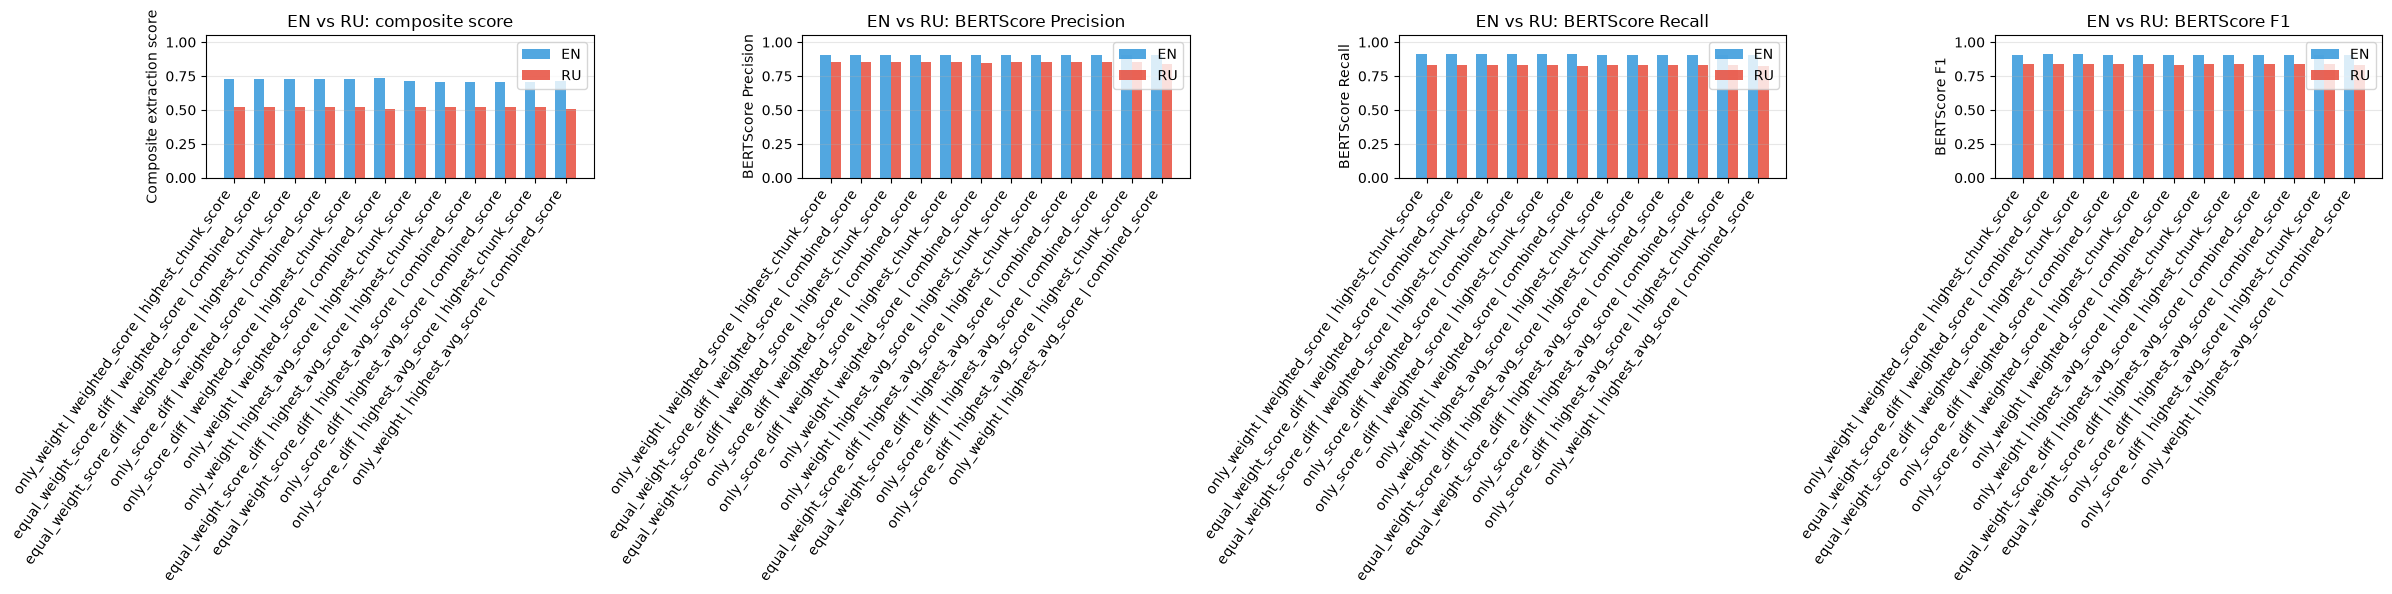

Сохранено: /home/aiserver/POLINA/UnTIE_project/experiments/analysis_results/extraction_metrics/en_ru_extraction_comparison.csv
Сохранено: /home/aiserver/POLINA/UnTIE_project/experiments/analysis_results/extraction_metrics/figures/en_ru_composite_comparison.png


In [9]:
if len(results) == 2:
    compare_cols = [
        "char_f1_mean",
        "token_f1_norm_mean",
        "rouge_l_f1_mean",
        "bertscore_p_mean",
        "bertscore_r_mean",
        "bertscore_f1_mean",
        "composite_extraction",
    ]
    en_summary = results["en"]["summary"][[c for c in compare_cols if c in results["en"]["summary"].columns]]
    ru_summary = results["ru"]["summary"][[c for c in compare_cols if c in results["ru"]["summary"].columns]]
    compare = en_summary.join(ru_summary, lsuffix="_en", rsuffix="_ru", how="inner")
    compare["delta_composite"] = compare["composite_extraction_ru"] - compare["composite_extraction_en"]
    compare["mean_composite"] = (
        compare["composite_extraction_en"] + compare["composite_extraction_ru"]
    ) / 2
    compare = compare.sort_values("mean_composite", ascending=False)

    compare_path = OUTPUT_DIR / "en_ru_extraction_comparison.csv"
    compare.to_csv(compare_path, encoding="utf-8")
    display(compare.head(12))

    top = compare.head(12).reset_index()
    top["strategy_combo"] = top[list(STRATEGY_COLUMNS)].agg(" | ".join, axis=1)
    x = np.arange(len(top))
    width = 0.35

    bertscore_metrics = [
        ("bertscore_p_mean", "BERTScore Precision"),
        ("bertscore_r_mean", "BERTScore Recall"),
        ("bertscore_f1_mean", "BERTScore F1"),
    ]
    available_bertscore = [
        (col, title)
        for col, title in bertscore_metrics
        if f"{col}_en" in top.columns and f"{col}_ru" in top.columns
    ]

    fig, axes = plt.subplots(1, 1 + len(available_bertscore), figsize=(6 * (1 + len(available_bertscore)), 6))
    if len(available_bertscore) == 0:
        axes = [axes]
    else:
        axes = list(np.atleast_1d(axes))

    axes[0].bar(x - width / 2, top["composite_extraction_en"], width, label="EN", color="#3498db", alpha=0.85)
    axes[0].bar(x + width / 2, top["composite_extraction_ru"], width, label="RU", color="#e74c3c", alpha=0.85)
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(top["strategy_combo"], rotation=55, ha="right")
    axes[0].set_ylim(0, 1.05)
    axes[0].set_ylabel("Composite extraction score")
    axes[0].set_title("EN vs RU: composite score")
    axes[0].legend()
    axes[0].grid(True, axis="y", alpha=0.3)

    for ax, (col, title) in zip(axes[1:], available_bertscore):
        ax.bar(x - width / 2, top[f"{col}_en"], width, label="EN", color="#3498db", alpha=0.85)
        ax.bar(x + width / 2, top[f"{col}_ru"], width, label="RU", color="#e74c3c", alpha=0.85)
        ax.set_xticks(x)
        ax.set_xticklabels(top["strategy_combo"], rotation=55, ha="right")
        ax.set_ylim(0, 1.05)
        ax.set_ylabel(title)
        ax.set_title(f"EN vs RU: {title}")
        ax.legend()
        ax.grid(True, axis="y", alpha=0.3)

    fig.tight_layout()
    out = FIGURES_DIR / "en_ru_composite_comparison.png"
    fig.savefig(out, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Сохранено: {compare_path}\nСохранено: {out}")
else:
    print("Сравнение EN/RU пропущено: загружен неполный набор файлов.")


## Примечания

- Метрики считаются через `untie.extraction_metrics` (логика из `scripts/04_Learning_text.ipynb`).
- Для ускорения метрики считаются один раз на уникальную пару `(final_answer, tasks_cleaned)` и мёрджатся обратно.
- `token_f1` из SQuAD в диапазоне 0–100; для графиков используется нормализованная колонка `token_f1_norm = token_f1 / 100`.
- BERTScore (`bertscore_p`, `bertscore_r`, `bertscore_f1`) автоматически добавляется в таблицы и графики, если колонки есть в scored-CSV или `INCLUDE_BERTSCORE = True`.
- Кэш scored-таблиц: `experiments/analysis_results/extraction_metrics/scored_{en,ru}.csv`. Для пересчёта установите `RECOMPUTE = True`.
- Строки с `--No valid answers--` исключаются до подсчёта метрик.
- Для RU дополнительно строится summary по evaluable-подмножеству (`strategy_applicable=True`).
